<a href="https://colab.research.google.com/github/favouroo/Tech-Crush-DS-Task-3-Coursework/blob/main/Task%203%20(ii)%20EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Task 3 Cleaned Dataset for EDA**

This notebook explores the data and answers all 10 questions in the task and also a few additional explorations.

First, import the necessary libraries used in the exploration of datasets.
Matplotlib and seaborn for data visualisation, numpy and pandas for numerical computing, data cleaning, data manipulation, etc.

In the next line of codes, I have imported the libraries, checked data for consistency, redundancy and accuracy by using some pandas methods to check for the **first 4 rows**, **null values**, **overview**, **statistical summary**, and **datatype conversion**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis

sns.set_theme()

In [ ]:
pizza_info = pd.read_csv("/content/all_pizza_data.csv")
pizza_info.head(4)

,order_details_id,order_id,transaction date,pizza_type_id,pizza_id,name,category,ingredients,size,price,quantity
0,11,6,2015-01-01 12:29:36,bbq_ckn,bbq_ckn_s,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,...",S,12.75,1
1,239,102,2015-01-02 17:54:04,bbq_ckn,bbq_ckn_s,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,...",S,12.75,1
2,294,124,2015-01-02 20:12:34,bbq_ckn,bbq_ckn_s,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,...",S,12.75,1
3,458,194,2015-01-03 21:21:24,bbq_ckn,bbq_ckn_s,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,...",S,12.75,1


In [ ]:
pizza_info.isna().sum().reset_index()

,index,0
0,order_details_id,0
1,order_id,0
2,transaction date,0
3,pizza_type_id,0
4,pizza_id,0
5,name,0
6,category,0
7,ingredients,0
8,size,0
9,price,0


In [ ]:
pizza_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_details_id  48620 non-null  int64  
 1   order_id          48620 non-null  int64  
 2   transaction date  48620 non-null  object 
 3   pizza_type_id     48620 non-null  object 
 4   pizza_id          48620 non-null  object 
 5   name              48620 non-null  object 
 6   category          48620 non-null  object 
 7   ingredients       48620 non-null  object 
 8   size              48620 non-null  object 
 9   price             48620 non-null  float64
 10  quantity          48620 non-null  int64  
dtypes: float64(1), int64(3), object(7)
memory usage: 4.1+ MB


In [ ]:
pizza_stat= pizza_info.describe()
pizza_stat_2sf = round(pizza_stat,2)
pizza_stat_2sf

,order_details_id,order_id,price,quantity
count,48620.00,48620.00,48620.00,48620.00
mean,24310.50,10701.48,16.49,1.02
std,14035.53,6180.12,3.62,0.14
min,1.00,1.00,9.75,1.00
25%,12155.75,5337.00,12.75,1.00
50%,24310.50,10682.50,16.50,1.00
75%,36465.25,16100.00,20.25,1.00
max,48620.00,21350.00,35.95,4.00


In [ ]:
#convert transaction date to datetime
pizza_info["transaction date"] = pd.to_datetime(pizza_info["transaction date"])
pizza_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_details_id  48620 non-null  int64         
 1   order_id          48620 non-null  int64         
 2   transaction date  48620 non-null  datetime64[ns]
 3   pizza_type_id     48620 non-null  object        
 4   pizza_id          48620 non-null  object        
 5   name              48620 non-null  object        
 6   category          48620 non-null  object        
 7   ingredients       48620 non-null  object        
 8   size              48620 non-null  object        
 9   price             48620 non-null  float64       
 10  quantity          48620 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(3), object(6)
memory usage: 4.1+ MB


Having ensured accuracy in the dataset, the next important thing is to answer each question

# **Q1: What is the total revenue/sales?**
To determine total revenue, we must first calculate the revenue for each sales made and to do this, we create a column named "***revenue***".

The value of revenue generated for each sale is gotten by multiplying price and order quantity/quantity sold. The next lines of code does just that.

In [ ]:
#to find total revenue for the year, first create column named revenue then sum it up
pizza_info["revenue"] = pizza_info["price"] * pizza_info["quantity"]
pizza_info.head(3)

,order_details_id,order_id,transaction date,pizza_type_id,pizza_id,name,category,ingredients,size,price,quantity,revenue
0,11,6,2015-01-01 12:29:36,bbq_ckn,bbq_ckn_s,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,...",S,12.75,1,12.75
1,239,102,2015-01-02 17:54:04,bbq_ckn,bbq_ckn_s,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,...",S,12.75,1,12.75
2,294,124,2015-01-02 20:12:34,bbq_ckn,bbq_ckn_s,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,...",S,12.75,1,12.75


In [ ]:
#total sum of revenue
tot_piz_sum = pizza_info["revenue"].sum()
tot_piz_rev = (f"{tot_piz_sum:,.2f}")
print(f"The total revenue realized from sales of pizza in the year 2015 is {tot_piz_rev}.")

The total revenue realized from sales of pizza in the year 2015 is 817,860.05.


From the above, we can see that the revenue generated for the sales of Pizza in the year 2015 was ***817,860.05 USD***.
I used USD because pizza is a staple food in America. Although it is originally an Italian food, it is widely consumed in the US.

# **Q2: Find the total quantity sold**
This question speaks to the amount of pizza sold, not the amount of orders taken or number of sales recorded. To do this, access the ***quantity*** column in the dataframe called "***pizza_info***" and sums it up.

In [ ]:
#total quantity sold
tot_qty_sold = pizza_info["quantity"].sum()
tqs = (f"{tot_qty_sold:,}")
print(f"The total quantity of pizza sold in the year 2015 is {tqs} pieces.")

The total quantity of pizza sold in the year 2015 is 49,574 pieces.


From the code and result above, the total quantity of pizza sold in 2015 is **49,574**.

# **Q3: Find the total orders**
This refers to the total number of sales/ order entries and we can get this from the "order_id" column. This is because every order has a unique id. There are a number of ways to find out. I have used two methods. Counting the unique order_id using the "***nunique***", "***value_counts***" and the "***groupby***" methods to get the answers.

In [ ]:
pizza_info["order_id"].nunique()

21350

In [ ]:
pizza_info["order_id"].value_counts()

,count
order_id,
10760,21
18845,21
13906,15
17464,15
18280,15
...,...
16325,1
16012,1
15233,1


In [ ]:
group_orders = pizza_info.groupby("order_id")
tot_orders= len(group_orders)
tot_piz_order = (f"{tot_orders:,}")
print(f"The total order of pizza taken in the year 2015 is {tot_piz_order}.")

The total order of pizza taken in the year 2015 is 21,350.


All the three methods above prove that there were **21350** pizza orders taken in the year 2015.

# **Q4: How many pizza types do they sell?**
Question 4 assks us to determine the number of pizza varieties the pizza shop sold in the year. We can find this out by counting the "***pizza_type_id***". Uisng value_counts and resetting the index or employing the groupby method.

When we use the value_count method, we see that our indexs count from 0 to 31. this infers that we have a total of 32 pizza types. The groupby method uses the len function to count how many groups were identified by the method.

In [ ]:
#to know the number of pizza_types they sell
pizza_info["pizza_type_id"].value_counts().reset_index()

,pizza_type_id,count
0,classic_dlx,2416
1,bbq_ckn,2372
2,hawaiian,2370
3,pepperoni,2369
4,thai_ckn,2315
5,cali_ckn,2302
6,spicy_ital,1887
7,sicilian,1887
8,southw_ckn,1885
9,four_cheese,1850


In [ ]:
#pizza types sold
group_pizza_type = pizza_info.groupby("pizza_type_id")
tot_pizza_type= len(group_pizza_type)
print(f"In 2015, the company had a total of {tot_pizza_type} different types of pizza.")

In 2015, the company had a total of 32 different types of pizza.


The company sold 32 varieties of pizza in that year alone.

# **Q5: Find the average price of the pizzas**
The average price of pizza is the mean amount per pizza. To find this, I created a variable named "***avg_pizza***" and found the mean price by accessing the price column in my cleaned dataset.

In [ ]:
#the average price of the pizzas
avg_price = pizza_info["price"].mean()
avg_2sf = round(avg_price, 2)
print(f"The average price of a pizza is {avg_2sf}.")

The average price of a pizza is 16.49.


In [ ]:
pizza_stat= pizza_info.select_dtypes(["float64", "int64"]).describe()
pizza_stat_2sf = round(pizza_stat,2)
pizza_stat_2sf

,order_details_id,order_id,price,quantity,revenue
count,48620.00,48620.00,48620.00,48620.00,48620.00
mean,24310.50,10701.48,16.49,1.02,16.82
std,14035.53,6180.12,3.62,0.14,4.44
min,1.00,1.00,9.75,1.00,9.75
25%,12155.75,5337.00,12.75,1.00,12.75
50%,24310.50,10682.50,16.50,1.00,16.50
75%,36465.25,16100.00,20.25,1.00,20.50
max,48620.00,21350.00,35.95,4.00,83.00


To confirm that, I used the describe method to get the statistical overview of my numericak columns and the **16.49 USD** is confirmed in the mean row, price column.

# **Q6: What are the peak hours of sales?**
The peak hours of sales are the hours where sales are made the most. To do this, it is best we visualize it.
I started by extracting the hours from the "***transaction date***" column, and then made another column from it, using "***.dt.hour***" because that is the most important variable to us now.

I calculated the peak hours of sale in terms of Revenue genration and in terms of order placement. The rational behind me doing it this way is because sometimes, more order doesn't mean more money/revenue. Factors like quantity and even price can affect it.

The next lines of codes achieves the following:
- Creates a column for hours
- Reorders the dataset using the hours column in descending order
- Creates a variable named "***rev_per_hour***", and sums up the revenue generated for each hour throughout the year.
- Using ***matplotlib***, I visualised the revenue generated throughout the year.

In [ ]:
#to get peak hours, create hours column
pizza_info["hours"] = pizza_info["transaction date"].dt.hour
pizza_info.head(3)

,order_details_id,order_id,transaction date,pizza_type_id,pizza_id,name,category,ingredients,size,price,quantity,revenue,hours
0,11,6,2015-01-01 12:29:36,bbq_ckn,bbq_ckn_s,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,...",S,12.75,1,12.75,12
1,239,102,2015-01-02 17:54:04,bbq_ckn,bbq_ckn_s,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,...",S,12.75,1,12.75,17
2,294,124,2015-01-02 20:12:34,bbq_ckn,bbq_ckn_s,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,...",S,12.75,1,12.75,20


In [ ]:
#sort by transation date in descending order
sort_descending = pizza_info.sort_values(by="transaction date", ascending=False)
sort_descending.head(4)

,order_details_id,order_id,transaction date,pizza_type_id,pizza_id,name,category,ingredients,size,price,quantity,revenue,hours
478,48620,21350,2015-12-31 23:02:05,bbq_ckn,bbq_ckn_s,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,...",S,12.75,1,12.75,23
44720,48619,21349,2015-12-31 22:09:54,mexicana,mexicana_l,The Mexicana Pizza,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",L,20.25,1,20.25,22
19293,48618,21348,2015-12-31 21:23:10,napolitana,napolitana_s,The Napolitana Pizza,Classic,"Tomatoes, Anchovies, Green Olives, Red Onions,...",S,12.00,1,12.00,21
40379,48617,21348,2015-12-31 21:23:10,four_cheese,four_cheese_l,The Four Cheese Pizza,Veggie,"Ricotta Cheese, Gorgonzola Piccante Cheese, Mo...",L,17.95,1,17.95,21


In [ ]:
rev_per_hour = pizza_info.groupby("hours")["revenue"].sum()
rev_per_hour.reset_index()

,hours,revenue
0,9,83.00
1,10,303.65
2,11,44935.80
3,12,111877.90
4,13,106065.70
5,14,59201.40
6,15,52992.30
7,16,70055.40
8,17,86237.45
9,18,89296.85


In [ ]:
rev_per_hour.index

Index([9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23], dtype='int32', name='hours')

In [ ]:
rev_per_hour.values

array([8.300000e+01, 3.036500e+02, 4.493580e+04, 1.118779e+05,
       1.060657e+05, 5.920140e+04, 5.299230e+04, 7.005540e+04,
       8.623745e+04, 8.929685e+04, 7.262890e+04, 5.821540e+04,
       4.202980e+04, 2.281515e+04, 1.121350e+03])

This plot has a width and height of [12.  8.] respectively


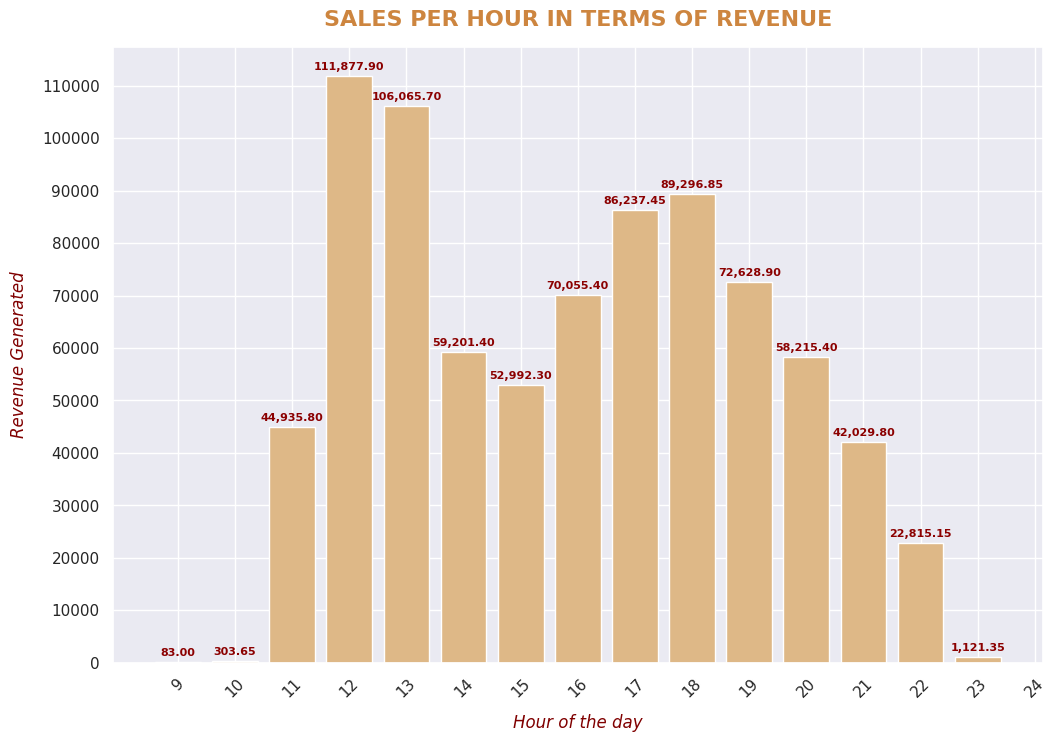

In [ ]:
plt.figure(figsize=(12,8)) #make the plot more visible by increasing height and width
print(f"This plot has a width and height of {plt.gcf().get_size_inches()} respectively") #to check the new width and height
bars= plt.bar(rev_per_hour.index, rev_per_hour.values, color = "burlywood")
plt.title("SALES PER HOUR IN TERMS OF REVENUE", fontsize= 16, color="peru", fontweight= "bold", pad = 15)
plt.xticks(range(9,25,1), rotation = 45)
plt.yticks(range(0, 120000, 10000))
plt.xlabel("Hour of the day", fontsize= 12, color="maroon", fontstyle= "italic", labelpad = 10)
plt.ylabel("Revenue Generated", fontsize= 12, color="maroon", fontstyle= "italic", labelpad = 10)
plt.bar_label(bars, padding = 3, color = "darkred", fontweight= "bold", fmt="{:,.2f}", fontsize = 8)

plt.show()

From the plotted graph of Revenue Generated against Hour of the Day, we can see that the ***peak hour*** of sales in terms of revenue is ***12pm***. This may be due to a number of factors. One being that many office work hours use any moment between ***12-2pm*** as break/lunch time.

However, the ***peak hours*** are— ***12pm, 1pm, 6pm, and 5pm***— in that order, assuming we're to select 4 peak hours based on "day" and "night".

The reason for daytime peak hours have already been established as lunch break. However, the nighttime peak hours are as a result of C.O.B (Close Of Business).

Work hours conventionally ends at ***5pm*** and sometimes, ***6pm*** in some places. At this time, workers are probably thinking of what to eat for dinner and the most viable option would be to eat pizza. This would explain the reason behind the increase in sales as opposed to revenue generated during the hours of ***2pm to 4:49pm***.

--------------------------------------------

To visualize this using Seaborn library, I had to convert the "***revenue_per_hour***" to a dataframe because in the seaborn library, one of the arguement is the the inclusion of the "dataset".

In [ ]:
#create a new dataframe for hours and revenue per hour
revenue_per_hour = pd.DataFrame({"hours": rev_per_hour.index, "revenue": rev_per_hour.values})
revenue_per_hour

,hours,revenue
0,9,83.00
1,10,303.65
2,11,44935.80
3,12,111877.90
4,13,106065.70
5,14,59201.40
6,15,52992.30
7,16,70055.40
8,17,86237.45
9,18,89296.85


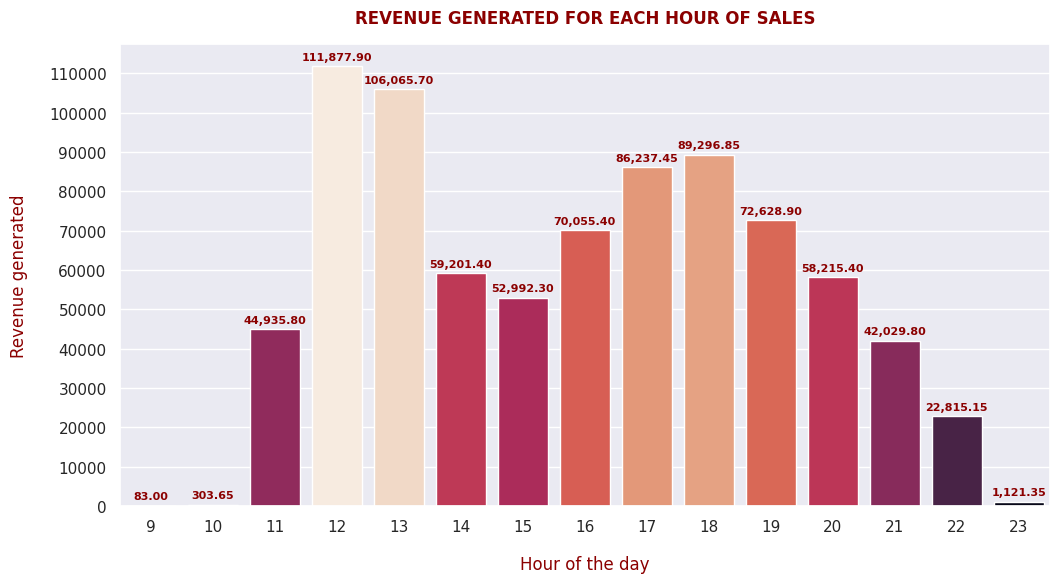

In [ ]:
#using sns baarplot for the same purpose
plt.figure(figsize=(12,6))
bars = sns.barplot(data = revenue_per_hour, y = "revenue", x= "hours", palette = "rocket", hue= "revenue", legend= False)
plt.title("REVENUE GENERATED FOR EACH HOUR OF SALES", pad=15, color = "darkred", fontweight = "bold")
plt.ylabel("Revenue generated", labelpad=15, color = "darkred")
plt.xlabel ("Hour of the day", labelpad=15, color = "darkred")
plt.yticks(np.arange(0, 120000, step= 10000))
for i in bars.containers:
    bars.bar_label(i, padding = 3, color = "darkred", fontweight="bold", fmt="{:,.2f}", fontsize = 8)
bars.tick_params(axis="y", length=6, width=1.5)

plt.show()

The plot above is the same as the initial plot, and has the same explanation. The only difference is the visualization library used.

----
In terms of order placement, the peak hours of sale(s) was also same as the peak hour(s) of sales. The next lines of code performs the following operations to visualize the **peak hours of sale in terms of order placement**:
- Creates a variable named "***order_hours***"
- Views our values in a dataframe
- Uses the countplot function in the seaborn library


In [ ]:
order_hours = pizza_info["hours"].value_counts()

In [ ]:
order_hours.index

Index([12, 13, 18, 17, 19, 16, 14, 20, 15, 11, 21, 22, 23, 10, 9], dtype='int32', name='hours')

In [ ]:
order_hours.values

array([6543, 6203, 5359, 5143, 4350, 4185, 3521, 3487, 3170, 2672, 2528,
       1370,   68,   17,    4])

In [ ]:
pizza_info["hours"].value_counts().sort_index().reset_index()

,hours,count
0,9,4
1,10,17
2,11,2672
3,12,6543
4,13,6203
5,14,3521
6,15,3170
7,16,4185
8,17,5143
9,18,5359


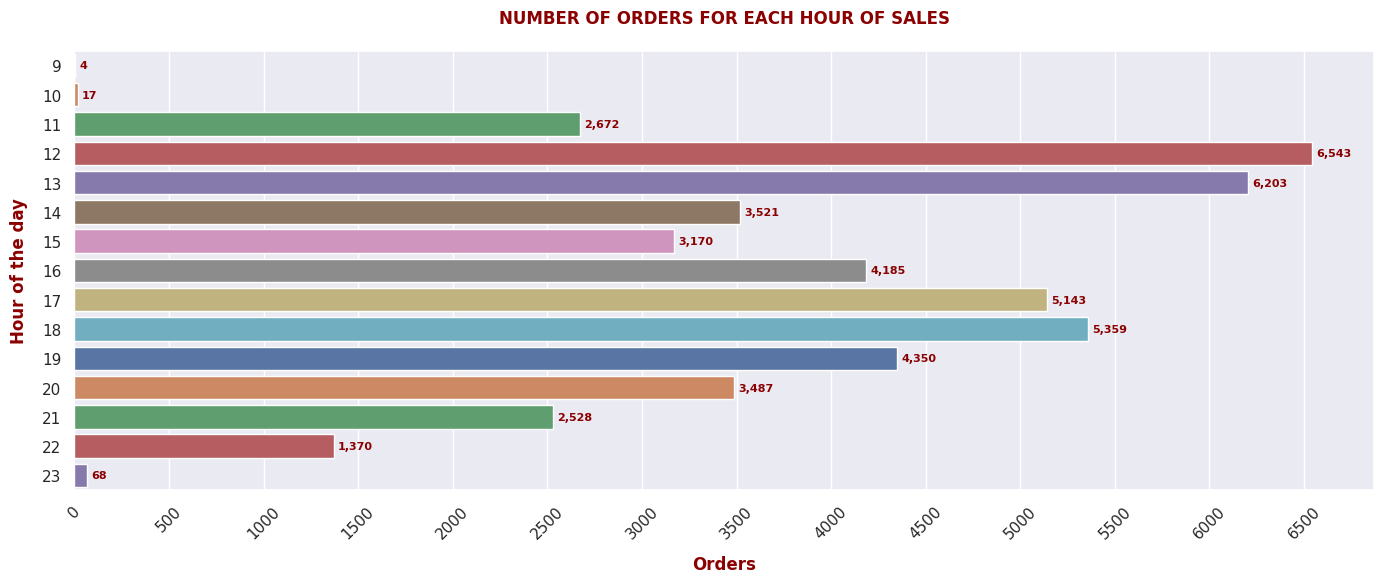

In [ ]:
plt.figure(figsize=(14,6)) #make the plot more visible by increasing height and width
bars= sns.countplot(data = pizza_info, y= "hours", palette = "deep", hue= "hours", legend = False)
plt.title("NUMBER OF ORDERS FOR EACH HOUR OF SALES", pad=20, color = "darkred", fontweight = "bold")
plt.ylabel("Hour of the day", labelpad=10, color="darkred", fontweight="bold")
plt.xlabel ("Orders", labelpad=10, color="darkred", fontweight="bold")
plt.xticks(range(0, 6501, 500), rotation = 45)
for i in bars.containers:
  bars.bar_label(i, padding= 3, color= "darkred", fontweight="bold", fmt="{:,.0f}", fontsize = 8)
plt.tight_layout()

plt.show()

The result of the graph above follows the same pattern for that of Revenue generated. The peak hours for daytime are **12 and 1pm** while for evening/nighttime is **5 and 6pm**. This is slightly logical because most of the order quantity were 1. People would likely buy for just themselves during the lunch breaks and same for takehomes.

The reason for the ***12pm, 1pm, 5pm and 6pm*** purchases still hold true.

# **Q7: Find the total sales made on each day of the week. Which day of the week is when sales are made the most?**
To do this, we must first have a column with the day extracted from the "***transaction date***" column using the "***.dt.day_name()***" method. This allows me know what day of the week the purchase was made. I also caalculated total sales in terms of revenue generated and in terms of order placement.

As earlier mentioneed, this is because sometimes, high order does not equate high revenue. On some days, they may have more orders on but low revenue and on some other days, they may have low orders but very high revenue will be realized. Major factors like price and quantity will also affect the outcome.


The next lines of codes carry out the following operations:
- Extracts the day name (e.g. Monday, Wednesday, Friday...)
- Uses the numerical way of naming days of the week to create a "***week order***" column
- Create a ***daily_sales*** dataframe for visualisation. In this dataframe, group by the "***day of week***" column, and reorder the days of the week using the "***day of week***" column so as to have a regular sequence.
-  Visualizes the necessary data using the barplot function in the seaborn library

In [ ]:
pizza_info["day of week"] = pizza_info["transaction date"].dt.day_name()
pizza_info.head(3)

,order_details_id,order_id,transaction date,pizza_type_id,pizza_id,name,category,ingredients,size,price,quantity,revenue,hours,day of week
0,11,6,2015-01-01 12:29:36,bbq_ckn,bbq_ckn_s,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,...",S,12.75,1,12.75,12,Thursday
1,239,102,2015-01-02 17:54:04,bbq_ckn,bbq_ckn_s,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,...",S,12.75,1,12.75,17,Friday
2,294,124,2015-01-02 20:12:34,bbq_ckn,bbq_ckn_s,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,...",S,12.75,1,12.75,20,Friday


In [ ]:
pizza_info["week order"] = pizza_info["transaction date"].dt.dayofweek
pizza_info.head(3)

,order_details_id,order_id,transaction date,pizza_type_id,pizza_id,name,category,ingredients,size,price,quantity,revenue,hours,day of week,week order
0,11,6,2015-01-01 12:29:36,bbq_ckn,bbq_ckn_s,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,...",S,12.75,1,12.75,12,Thursday,3
1,239,102,2015-01-02 17:54:04,bbq_ckn,bbq_ckn_s,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,...",S,12.75,1,12.75,17,Friday,4
2,294,124,2015-01-02 20:12:34,bbq_ckn,bbq_ckn_s,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,...",S,12.75,1,12.75,20,Friday,4


In [ ]:
daily_sales= pizza_info.groupby(["day of week", "week order"])["revenue"].sum().reset_index().sort_values(by= "week order")
daily_sales

,day of week,week order,revenue
1,Monday,0,107329.55
5,Tuesday,1,114133.80
6,Wednesday,2,114408.40
4,Thursday,3,123528.50
0,Friday,4,136073.90
2,Saturday,5,123182.40
3,Sunday,6,99203.50


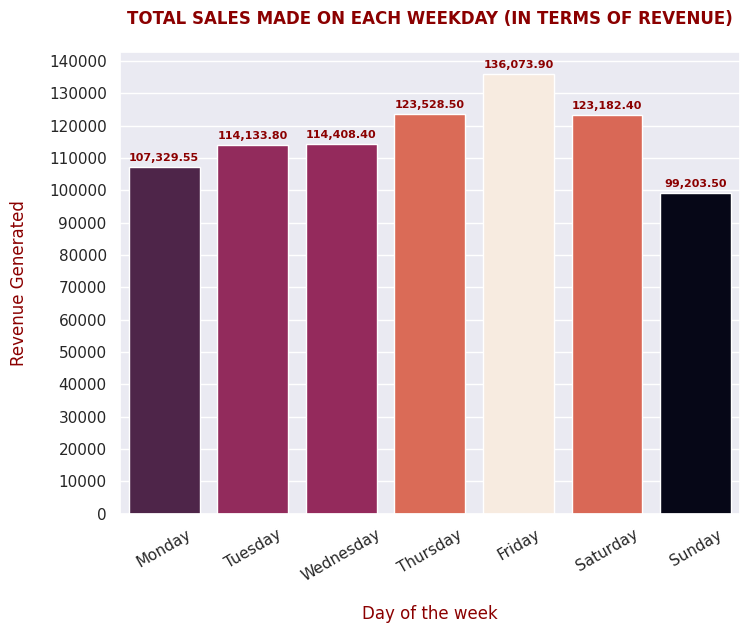

In [ ]:
plt.figure(figsize=(8,6))
bars= sns.barplot(data = daily_sales, y = "revenue", x= "day of week", palette = "rocket", hue= "revenue", legend= False)
plt.title("TOTAL SALES MADE ON EACH WEEKDAY (IN TERMS OF REVENUE)", pad=20, color = "darkred", fontweight = "bold")
plt.ylabel("Revenue Generated", labelpad=15, color = "darkred")
plt.xlabel ("Day of the week", labelpad=15, color = "darkred")
plt.yticks(range(0, 140001, 10000))
plt.xticks(rotation = 30)
for i in bars.containers:
  bars.bar_label(i, padding= 3, color= "darkred", fontweight="bold", fmt="{:,.2f}", fontsize = 8)


plt.show()

From the chart above, we can see that Friday yields the most revenue, with a total of **136,073.90 USD** in the year. This is quite reasonable. The rationale behind this may mostly be because Friday is uually the last work day and because pizza is not necessarily a full meal but a comfort food, people are most likely to use pizza as the weekend entry meal.

Also, sometimes, people often prefer to cook new meals over the weekend. So if there are no left overs in the fridges/freezers, a fast food like pizza is going to be a go to choice.

This is followed by Thursday and Saturday (**123,528.50** and **123,182.40** respectively); Hybrid work may explain the reason for the high yield on Thursday depeneding on company's policy. However, the explanation for Saturday's high yield would still be same as that of Friday — preparation for the new week may require new meals prep. A good way to end the week with respect to food is to eat out.

In [ ]:
sales_per_day = pizza_info[["day of week", "week order"]].value_counts().reset_index().sort_values(by= "week order")
sales_per_weekday = pd.DataFrame(sales_per_day)
sales_per_weekday

,day of week,week order,count
5,Monday,0,6369
4,Tuesday,1,6753
3,Wednesday,2,6797
2,Thursday,3,7323
0,Friday,4,8106
1,Saturday,5,7355
6,Sunday,6,5917


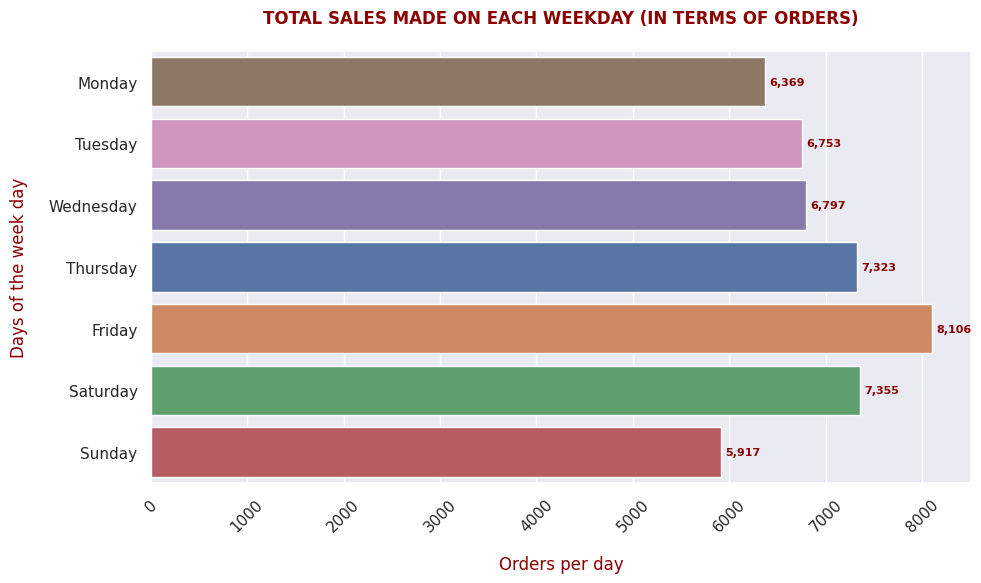

In [ ]:
plt.figure(figsize=(10,6))
week_day_order = sales_per_weekday["day of week"].tolist()
bars= sns.countplot(data = pizza_info, y= "day of week", order=week_day_order, palette= "deep", hue= "day of week", legend=False)
plt.title("TOTAL SALES MADE ON EACH WEEKDAY (IN TERMS OF ORDERS)", pad=20, color = "darkred", fontweight = "bold")
plt.ylabel("Days of the week day", labelpad=15, color = "darkred")
plt.xlabel ("Orders per day", labelpad=15, color = "darkred")
plt.xticks(rotation = 45)
for i in bars.containers:
  bars.bar_label(i, padding= 3, color= "darkred", fontweight="bold", fmt="{:,.0f}", fontsize = 8)
plt.tight_layout()


plt.show()

The chart of ***Week day*** against ***order*** shows a slightly different pattern from the chart in terms of revenue generated.

Here, we see that Friday still has the highest number of orders and it logically satisfies the possibility of more monetary yield.

This is however followed by ***SATURDAY*** then ***THURSDAY***. As opposed to the revenue generation chart with an order placement of **7,355** and **7,323** respectively. This makes so much sense because leading up from friday, the next day for the weekend is Satuurday. And in many homes (using Nigeria as an example), Saturdays are for less time-consuming meals therefore people tend to order more. Another reason could be visits — from having friends over to visiting friends and families.


# **Q8: Find the top 5 bestselling pizzas**
The top 5 best selling pizza is determined in the next set of code cells. To achieve visualizing this I first extracted the necessary columns from my cleaned data, created a dataframe.

Just like the two preceding questions, I have also answered this question in terms of revenue and in terms of orders. Sometimes, the most ordered pizza is not the pizza with the highest revenue yield.

The next set of codes executes these operations:
- Creates a dataframe with the name "***top_5_pizza***". This contains just the top 5 pizza types that are performing well in sales, when considering order placement.
- Creates a dataframe with the name "***pizza_count***". This contains top 15 best selling pizzas from the dataset considering order placement.
- Visualizes the dataframe using the sns.barplots to show all 15 out of the 32 pizza types.
- Visualizes just the first 5 best selling pizza using the countplot and I applied the "***.tolist()***" method.
- Views the data by categories to exploroe the ingredient and so as to draw insight from my visualised data

In [ ]:
#top 5 pizza
top_5 = pd.DataFrame(pizza_info[["pizza_type_id", "name"]].value_counts().sort_values(ascending=False))
top_5_pizza= top_5.head().reset_index()
top_5_pizza

,pizza_type_id,name,count
0,classic_dlx,The Classic Deluxe Pizza,2416
1,bbq_ckn,The Barbecue Chicken Pizza,2372
2,hawaiian,The Hawaiian Pizza,2370
3,pepperoni,The Pepperoni Pizza,2369
4,thai_ckn,The Thai Chicken Pizza,2315


In [ ]:
#top 15 pizza
pizza_count = pd.DataFrame(pizza_info[["name"]].value_counts().sort_values(ascending=False))
pizza_count= top_5.head(15).reset_index()
pizza_count

,pizza_type_id,name,count
0,classic_dlx,The Classic Deluxe Pizza,2416
1,bbq_ckn,The Barbecue Chicken Pizza,2372
2,hawaiian,The Hawaiian Pizza,2370
3,pepperoni,The Pepperoni Pizza,2369
4,thai_ckn,The Thai Chicken Pizza,2315
5,cali_ckn,The California Chicken Pizza,2302
6,sicilian,The Sicilian Pizza,1887
7,spicy_ital,The Spicy Italian Pizza,1887
8,southw_ckn,The Southwest Chicken Pizza,1885
9,four_cheese,The Four Cheese Pizza,1850


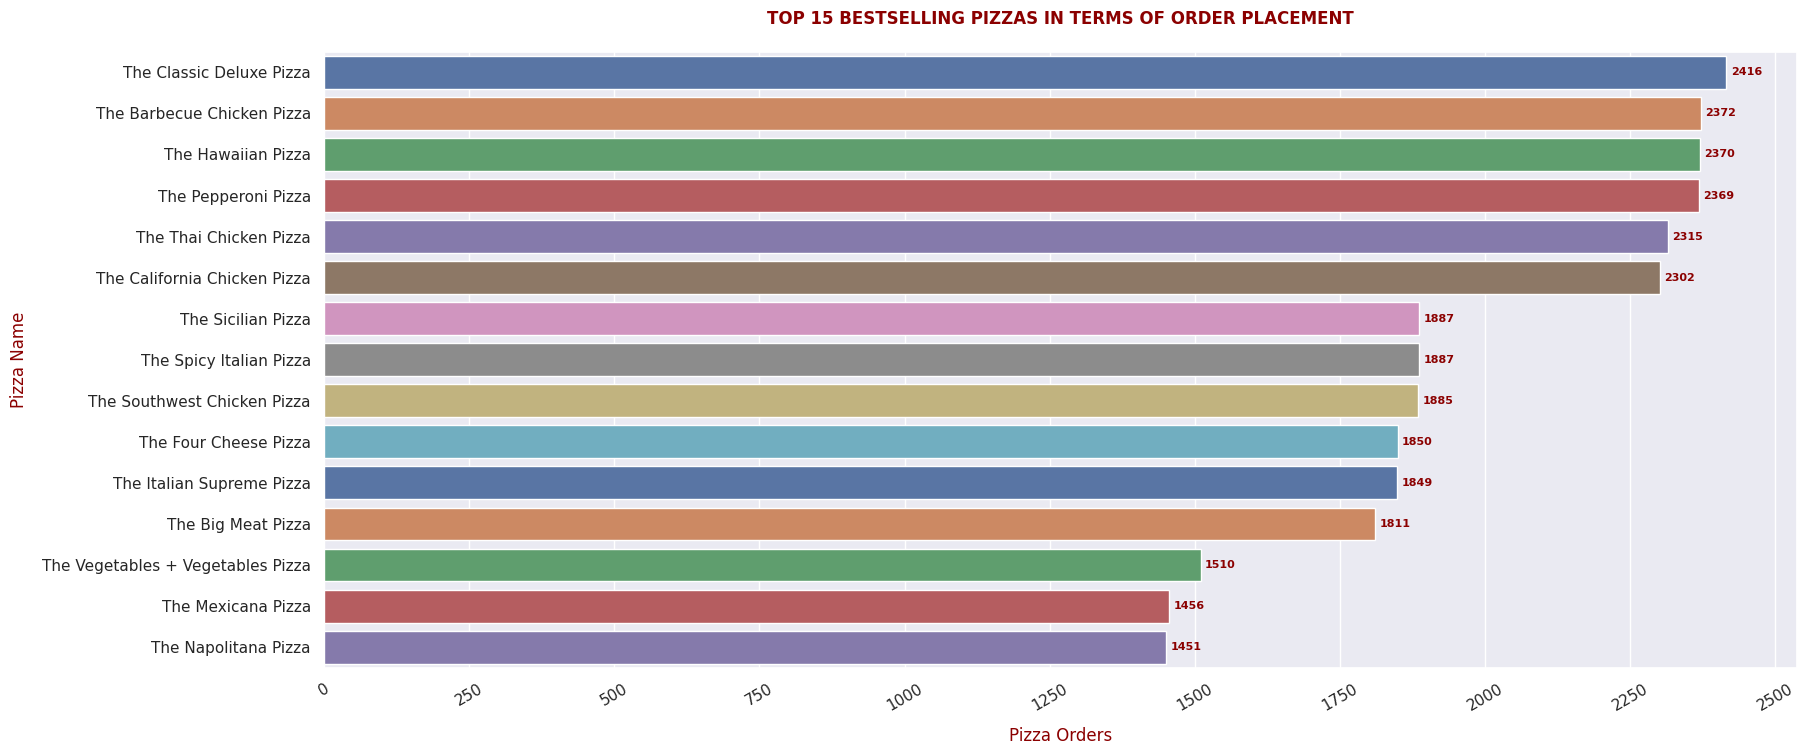

In [ ]:
plt.figure(figsize=(19,8))
bars= sns.barplot(data= pizza_count, x="count", y="name", palette="deep", hue="name", legend=False)
plt.title("TOP 15 BESTSELLING PIZZAS IN TERMS OF ORDER PLACEMENT", pad=20, color = "darkred", fontweight = "bold")
plt.ylabel("Pizza Name", labelpad=10, color = "darkred")
plt.xlabel ("Pizza Orders", labelpad=10, color="darkred")
plt.xticks(range(0, 2501, 250), rotation = 30)

for i in bars.containers:
  bars.bar_label(i, padding=3, color="darkred", fontweight="bold", fontsize=8)

plt.show()

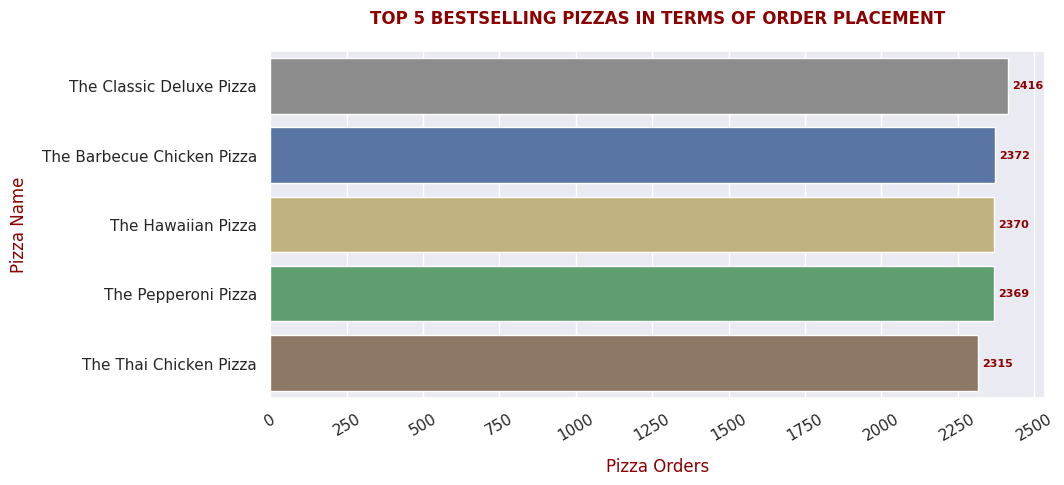

In [ ]:
plt.figure(figsize=(10,4.5))
top_5_piz = top_5_pizza["name"].tolist()
bars= sns.countplot(data = pizza_info, y= "name", order=top_5_piz, palette= "deep", hue ="pizza_type_id",  legend=False)
plt.title("TOP 5 BESTSELLING PIZZAS IN TERMS OF ORDER PLACEMENT", pad=20, color = "darkred", fontweight = "bold")
plt.ylabel("Pizza Name", labelpad=10, color = "darkred")
plt.xlabel ("Pizza Orders", labelpad=10, color = "darkred")
plt.xticks(range(0,2501,250), rotation = 30)
for i in bars.containers:
  bars.bar_label(i, padding=3, color="darkred",fontweight="bold", fontsize= 8)

plt.show()

In [ ]:
pizza_info.head()

,order_details_id,order_id,transaction date,pizza_type_id,pizza_id,name,category,ingredients,size,price,quantity,revenue,hours,day of week,week order
0,11,6,2015-01-01 12:29:36,bbq_ckn,bbq_ckn_s,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,...",S,12.75,1,12.75,12,Thursday,3
1,239,102,2015-01-02 17:54:04,bbq_ckn,bbq_ckn_s,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,...",S,12.75,1,12.75,17,Friday,4
2,294,124,2015-01-02 20:12:34,bbq_ckn,bbq_ckn_s,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,...",S,12.75,1,12.75,20,Friday,4
3,458,194,2015-01-03 21:21:24,bbq_ckn,bbq_ckn_s,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,...",S,12.75,1,12.75,21,Saturday,5
4,489,208,2015-01-04 12:12:05,bbq_ckn,bbq_ckn_s,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,...",S,12.75,1,12.75,12,Sunday,6


In [ ]:
pizza_info.groupby(["category", "ingredients"])["name"].value_counts()

category  ingredients                                                                                        name                                      
Chicken   Barbecued Chicken, Red Peppers, Green Peppers, Tomatoes, Red Onions, Barbecue Sauce                The Barbecue Chicken Pizza                    2372
          Chicken, Artichoke, Spinach, Garlic, Jalapeno Peppers, Fontina Cheese, Gouda Cheese                The California Chicken Pizza                  2302
          Chicken, Pineapple, Tomatoes, Red Peppers, Thai Sweet Chilli Sauce                                 The Thai Chicken Pizza                        2315
          Chicken, Red Onions, Red Peppers, Mushrooms, Asiago Cheese, Alfredo Sauce                          The Chicken Alfredo Pizza                      980
          Chicken, Tomatoes, Red Peppers, Red Onions, Jalapeno Peppers, Corn, Cilantro, Chipotle Sauce       The Southwest Chicken Pizza                   1885
          Chicken, Tomatoes, Red Peppers, Spinach, Garlic, Pesto Sauce                                       The Chicken Pesto Pizza                        961
Classic   Bacon, Pepperoni, Italian Sausage, Chorizo Sausage                                                 The Big Meat Pizza                            1811
          Capocollo, Red Peppers, Tomatoes, Goat Cheese, Garlic, Oregano                                     The Italian Capocollo Pizza                   1414
          Kalamata Olives, Feta Cheese, Tomatoes, Garlic, Beef Chuck Roast, Red Onions                       The Greek Pizza                               1406
          Mozzarella Cheese, Pepperoni                                                                       The Pepperoni Pizza                           2369
          Pepperoni, Mushrooms, Green Peppers                                                                The Pepperoni, Mushroom, and Peppers Pizza    1342
          Pepperoni, Mushrooms, Red Onions, Red Peppers, Bacon                                               The Classic Deluxe Pizza                      2416
          Sliced Ham, Pineapple, Mozzarella Cheese                                                           The Hawaiian Pizza                            2370
          Tomatoes, Anchovies, Green Olives, Red Onions, Garlic                                              The Napolitana Pizza                          1451
Supreme   Brie Carre Cheese, Prosciutto, Caramelized Onions, Pears, Thyme, Garlic                            The Brie Carre Pizza                           480
          Calabrese Salami, Capocollo, Tomatoes, Red Onions, Green Olives, Garlic                            The Italian Supreme Pizza                     1849
          Capocollo, Tomatoes, Goat Cheese, Artichokes, Peperoncini verdi, Garlic                            The Spicy Italian Pizza                       1887
          Coarse Sicilian Salami, Tomatoes, Green Olives, Luganega Sausage, Onions, Garlic                   The Sicilian Pizza                            1887
          Genoa Salami, Capocollo, Pepperoni, Tomatoes, Asiago Cheese, Garlic                                The Pepper Salami Pizza                       1422
          Nduja Salami, Pancetta, Tomatoes, Red Onions, Friggitello Peppers, Garlic                          The Calabrese Pizza                            927
          Prosciutto di San Daniele, Arugula, Mozzarella Cheese                                              The Prosciutto and Arugula Pizza              1428
          Soppressata Salami, Fontina Cheese, Mozzarella Cheese, Mushrooms, Garlic                           The Soppressata Pizza                          957
          Spinach, Red Onions, Pepperoni, Tomatoes, Artichokes, Kalamata Olives, Garlic, Asiago Cheese       The Spinach Supreme Pizza                      940
Veggie    Eggplant, Artichokes, Tomatoes, Zucchini, Red Peppers, Garlic, Pesto Sauce                         The Italian Vegetables Pizza                   975
        

From the two charts above we can tell that the top 5 performing pizzas in terms of order placement are **"the classic deluxe pizza", "the barbecue chicken pizza", "the Hawaiian pizza","the pepperoni pizza", "the Thai chicken pizza"** with a count of **2416**, **2372**, **2370**, **2369** and **2315** respectively.

The top 5 best selling pizza are all within the same range of 100 orders between them (2315-2416). And from grouping them into categories, we see that the best performing pizzas fall within the Chicken/Classic category. Almost all non-vegetarian loves chicken. This would explain for the presence of two pizzas in the chicken category making it to the top 5 orders. Another reason will be the presence of the some sort of protein in the ingredients.

Everyone likes to enjoy something chewy like beef, pork, pepperoni, ham, chicken, capocollo or any type of meat/fish in their meals. This too, will most likely explain the reason for the two categories making it to the top 5.

---
The next set of codeblocks helps us visualize the top 15 and top 5 pizzazs in terms of revenue generation. The sequential operations include:
- Creating a dataframe for categorizing pizza by revenue
- Using barplot to visualize the first 15 most excelling pizza in terms of revenue
- Another dataframe specifically for the top 5 bestselling pizza is created.
- Visualisinng the information on a bar plot chart.

In [ ]:
pizza_by_rev= pizza_info.groupby("name")["revenue"].sum().reset_index
pizza_by_rev = pd.DataFrame(pizza_by_rev())
pizza_by_rev= pizza_by_rev.sort_values(by = "revenue", ascending=False).head(15)
pizza_by_rev

,name,revenue
30,The Thai Chicken Pizza,43434.25
0,The Barbecue Chicken Pizza,42768.00
4,The California Chicken Pizza,41409.50
7,The Classic Deluxe Pizza,38180.50
26,The Spicy Italian Pizza,34831.25
25,The Southwest Chicken Pizza,34705.75
14,The Italian Supreme Pizza,33476.75
12,The Hawaiian Pizza,32273.25
9,The Four Cheese Pizza,32265.70
23,The Sicilian Pizza,30940.50


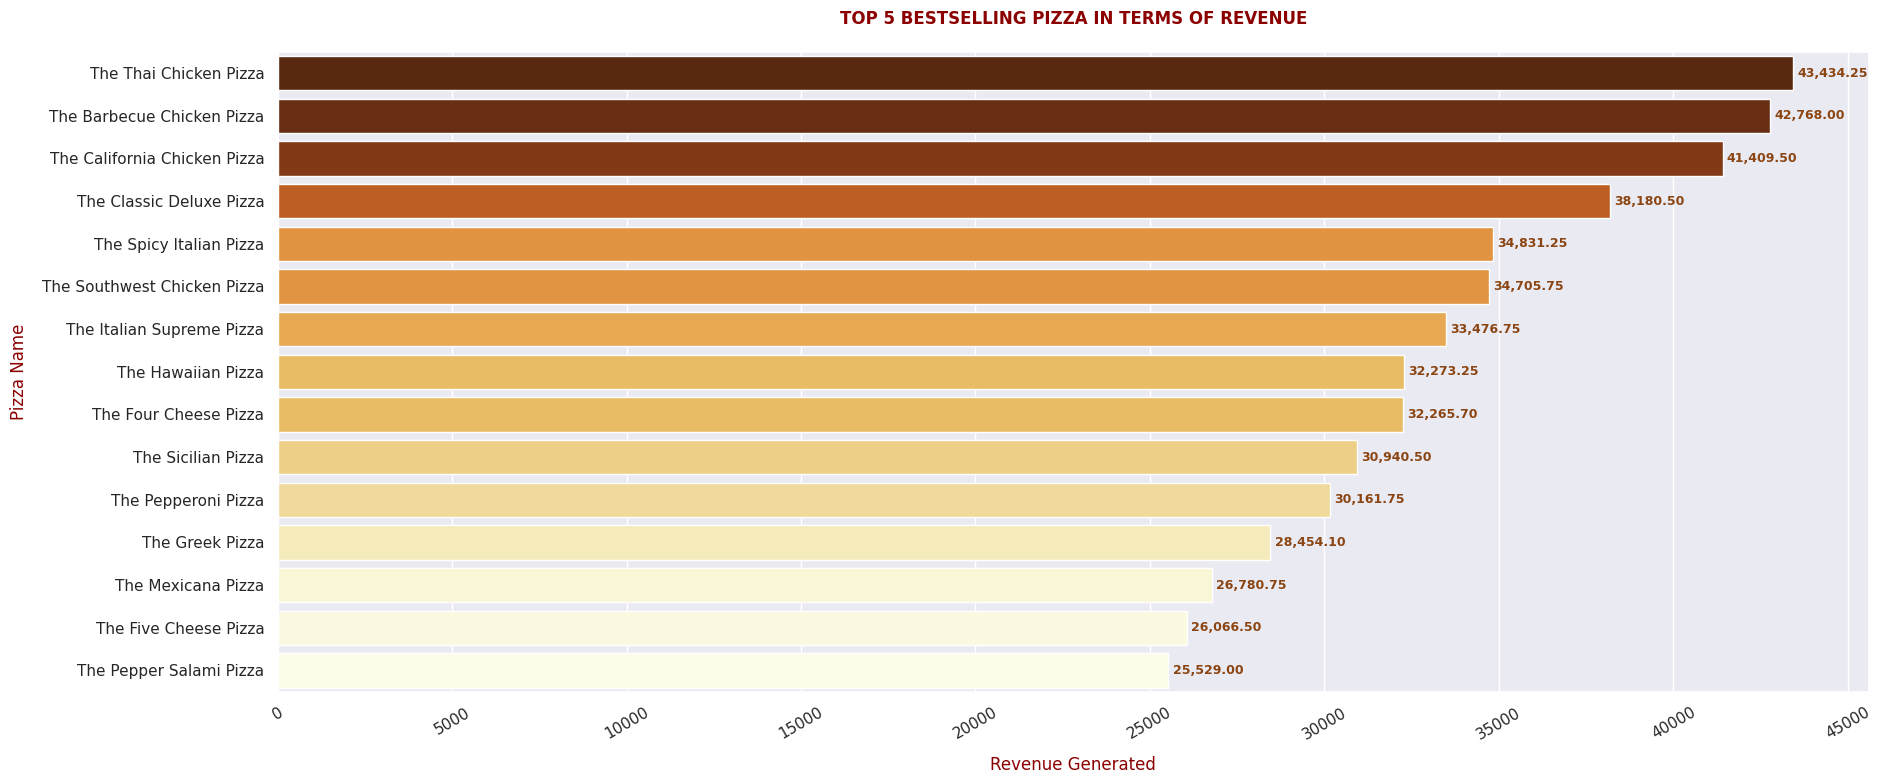

In [ ]:
#top 5 pizza bestselling pizza in terms of revenue
plt.figure(figsize=(19,8))
bars = sns.barplot(data = pizza_by_rev, y = "name", x="revenue", palette = "YlOrBr", hue= "revenue", legend= False)
plt.title("TOP 5 BESTSELLING PIZZA IN TERMS OF REVENUE", pad=20, color = "darkred", fontweight = "bold")
plt.ylabel("Pizza Name", labelpad=10, color = "darkred")
plt.xlabel ("Revenue Generated", labelpad=10, color = "darkred")

plt.xticks(range(0, 45001, 5000), rotation= 30)
plt.tight_layout()
for i in bars.containers:
    bars.bar_label(i, fmt="{:,.2f}", padding=3, fontsize=9, fontweight="bold", color= "saddlebrown")

plt.show()

In [ ]:
top_5_pizza_by_rev = pd.DataFrame(pizza_by_rev)
top_5_pizza_by_rev = top_5_pizza_by_rev.sort_values(by="revenue", ascending=False).head()
top_5_pizza_by_rev

,name,revenue
30,The Thai Chicken Pizza,43434.25
0,The Barbecue Chicken Pizza,42768.00
4,The California Chicken Pizza,41409.50
7,The Classic Deluxe Pizza,38180.50
26,The Spicy Italian Pizza,34831.25


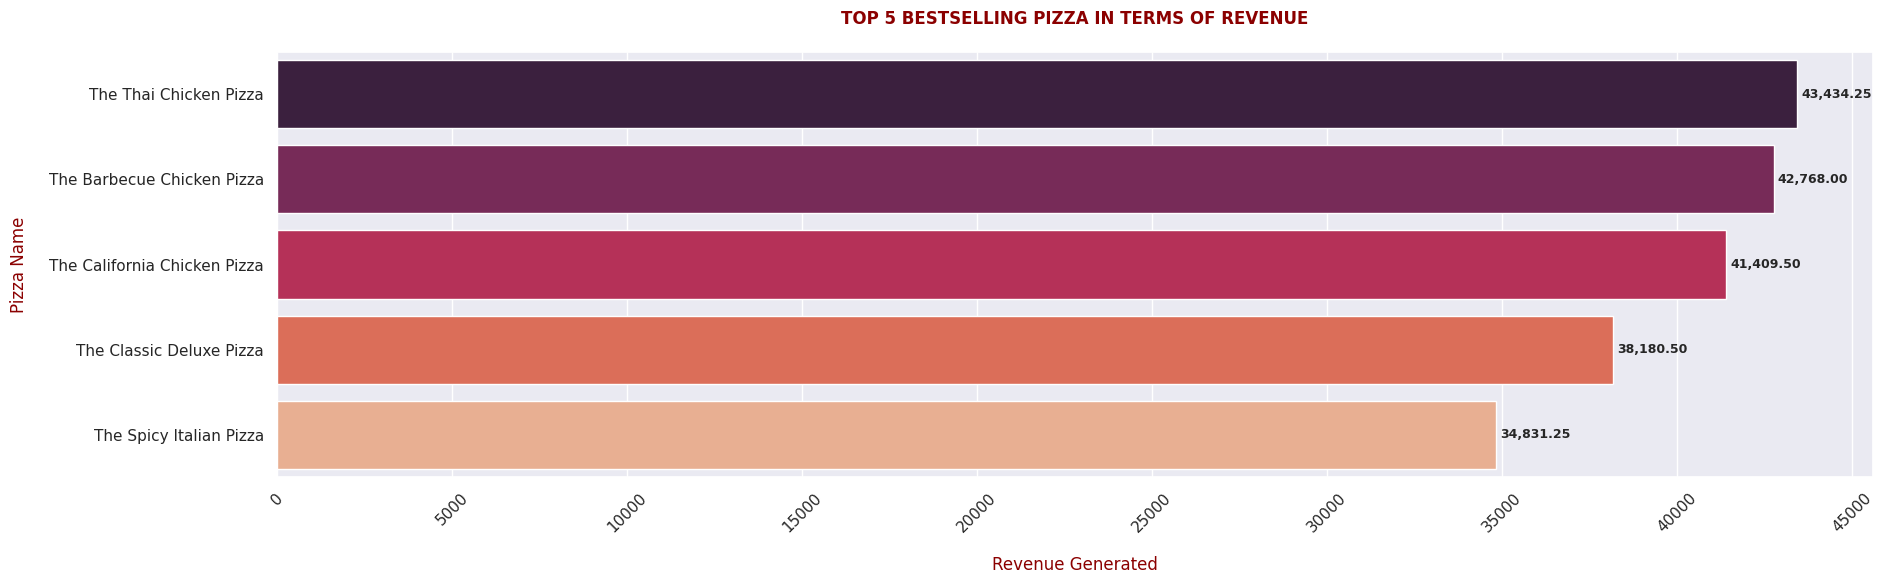

In [ ]:
#top 5 pizza bestselling pizza in terms of revenue
plt.figure(figsize=(19,6))
bars = sns.barplot(data = top_5_pizza_by_rev, y = "name", x="revenue", palette = "rocket", hue= "name", legend= False)
plt.title("TOP 5 BESTSELLING PIZZA IN TERMS OF REVENUE", pad=20, color = "darkred", fontweight = "bold")
plt.ylabel("Pizza Name", labelpad=15, color = "darkred")
plt.xlabel ("Revenue Generated", labelpad=15, color = "darkred")

plt.xticks(range(0, 45001, 5000), rotation= 45)
plt.tight_layout()
for i in bars.containers:
    bars.bar_label(i, fmt="{:,.2f}", padding=3, fontsize=9, fontweight="bold")
plt.tight_layout()

plt.show()

From the charts above, we can see that the pizza with the highest order is not the pizza with the highest revenue generation capacity.

The most ordered **Classic Deluxe Pizza** sits at **the fourth position in terms of revenue generation** and **The Thai Chicken Pizza** which was the fifth most ordered pizza generated the most revenue. We can also see the difference inn revenue (**5,25.75 USD**).

A major observation is that the pizzas with chicken generated the most revenue (they occupy first, second and third place). This explains my early statement that almost all non-vegetarians love chicken. It shows that people are willing to spend more on chicken-related pizza.

This is however followed by a pizza in the classic category and a pizza in the supreme category. These two pizzas, Classic Deluxe and Spicy Italian contain Pepperoni and Capocollo respectively and it further buttresses my point that people love to eat some sort of protein in whatever they eat.

# **Q9: Find the sales made in each month. Any trend noticeable?**
This question is about finding the toal sales made in each month and finding the trends. Trends are best visualized using line charts.

But before visualizing, the steps followed in analysing the sales by month includes:
- creating a column for month name and another column for month number to have the months in letters/words (January to December) and their nnumerical counterparts(1-12)
- Creating a dataframe named "***sales_per_month***" for the purpose of visualization
- using the line plot to see trends in sales for the different months
- Visualing the revenue generated for each month
- Visualizing maximum and minimum revenue generated
- Visualizes the average revenue when a pizza is sold

In [ ]:
pizza_info["month name"] = pd.to_datetime(pizza_info["transaction date"]).dt.month_name()
pizza_info["month number"] = pd.to_datetime(pizza_info["transaction date"]).dt.month
pizza_info.head()

,order_details_id,order_id,transaction date,pizza_type_id,pizza_id,name,category,ingredients,size,price,quantity,revenue,hours,day of week,week order,month name,month number
0,11,6,2015-01-01 12:29:36,bbq_ckn,bbq_ckn_s,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,...",S,12.75,1,12.75,12,Thursday,3,January,1
1,239,102,2015-01-02 17:54:04,bbq_ckn,bbq_ckn_s,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,...",S,12.75,1,12.75,17,Friday,4,January,1
2,294,124,2015-01-02 20:12:34,bbq_ckn,bbq_ckn_s,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,...",S,12.75,1,12.75,20,Friday,4,January,1
3,458,194,2015-01-03 21:21:24,bbq_ckn,bbq_ckn_s,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,...",S,12.75,1,12.75,21,Saturday,5,January,1
4,489,208,2015-01-04 12:12:05,bbq_ckn,bbq_ckn_s,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,...",S,12.75,1,12.75,12,Sunday,6,January,1


In [ ]:
#sales made in each month, in terms of revenue
sales_per_month = pizza_info.groupby(["month name", "month number"])["revenue"].agg(["sum", "mean"]).reset_index().sort_values(by="month number", ascending=True)
sales_per_month= pd.DataFrame(sales_per_month)
sales_per_month

,month name,month number,sum,mean
4,January,1,69793.30,16.793383
3,February,2,65159.60,16.741932
7,March,3,70397.10,16.817272
0,April,4,68736.80,16.901106
8,May,5,71402.75,16.844244
6,June,6,68230.20,16.951602
5,July,7,72557.90,16.870007
1,August,8,68278.25,16.677638
11,September,9,64180.05,16.805460
10,October,10,64027.60,16.862681


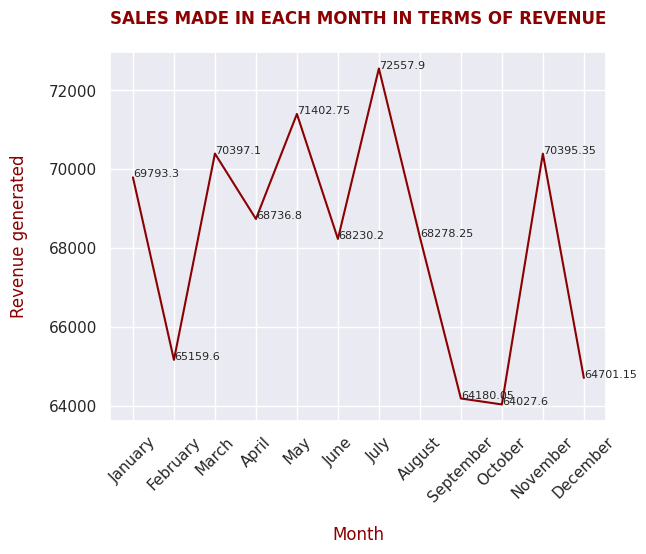

In [ ]:
sales_per_month
plt.plot(sales_per_month["month name"], sales_per_month["sum"], color = "darkred")
plt.title("SALES MADE IN EACH MONTH IN TERMS OF REVENUE", pad=20, color = "darkred", fontweight = "bold")
plt.xlabel("Month", labelpad=15, color = "darkred")
plt.ylabel("Revenue generated", labelpad=15, color = "darkred")
plt.xticks(rotation = 45)


for i in range(len(sales_per_month)):
    plt.text(sales_per_month["month name"][i], sales_per_month["sum"][i], sales_per_month["sum"][i], fontsize= 8)

plt.show()

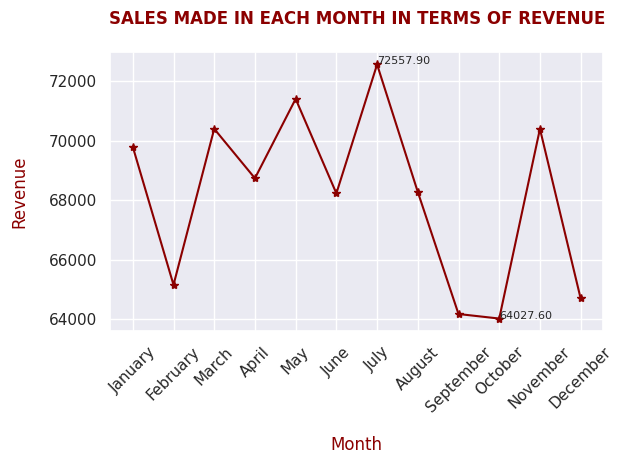

In [ ]:
sales_per_month
plt.plot(sales_per_month["month name"], sales_per_month["sum"], color = "darkred", marker= "*")
plt.title("SALES MADE IN EACH MONTH IN TERMS OF REVENUE", pad=20, color = "darkred", fontweight = "bold")
plt.xlabel("Month", labelpad=15, color = "darkred")
plt.ylabel("Revenue", labelpad=15, color = "darkred")
plt.xticks(rotation = 45)

#to get the row with the maximum and minimum revenue, we'll use loc and idmax
max_rev_row = sales_per_month.loc[sales_per_month["sum"].idxmax()]
min_rev_row = sales_per_month.loc[sales_per_month["sum"].idxmin()]

#to dd text labels for max and min revenue points
plt.text(max_rev_row["month name"], max_rev_row["sum"], f"{max_rev_row["sum"]:.2f}", fontsize=8)
plt.text(min_rev_row["month name"], min_rev_row["sum"], f"{min_rev_row["sum"]:.2f}", fontsize=8)

plt.tight_layout()

plt.show()

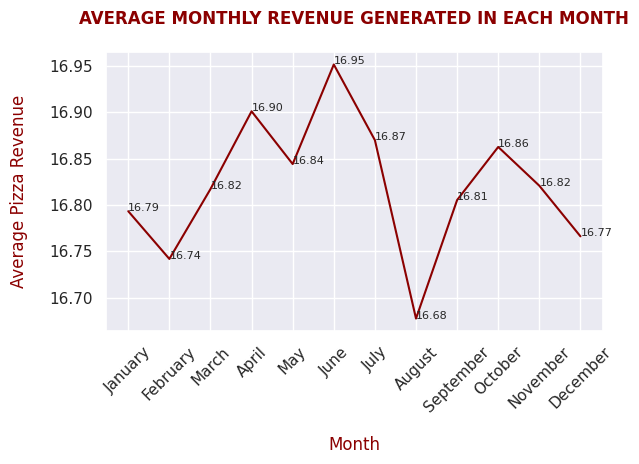

In [ ]:
sales_per_month
plt.plot(sales_per_month["month name"], sales_per_month["mean"], color = "darkred")
plt.title("AVERAGE MONTHLY REVENUE GENERATED IN EACH MONTH", pad=20, color = "darkred", fontweight = "bold")
plt.xlabel("Month", labelpad=15, color = "darkred")
plt.ylabel("Average Pizza Revenue", labelpad=15, color = "darkred")
plt.xticks(rotation = 45)
plt.tight_layout()

for i in range(len(sales_per_month)):
    plt.text(sales_per_month["month name"][i], sales_per_month["mean"][i], f"{sales_per_month["mean"][i]:.2f}", fontsize= 8)

plt.show()

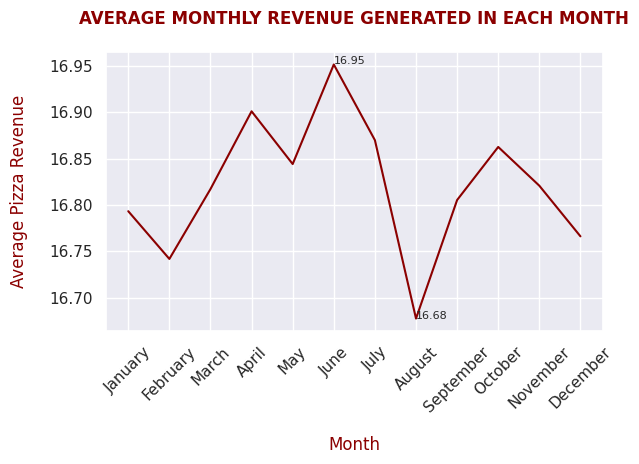

In [ ]:
sales_per_month
plt.plot(sales_per_month["month name"], sales_per_month["mean"], color = "darkred")
plt.title("AVERAGE MONTHLY REVENUE GENERATED IN EACH MONTH", pad=20, color = "darkred", fontweight = "bold")
plt.xlabel("Month", labelpad=15, color = "darkred")
plt.ylabel("Average Pizza Revenue", labelpad=15, color = "darkred")
plt.xticks(rotation = 45)
plt.tight_layout()

#to locaate the months with the maximum and minimum average prize of pizza sales,
max_rev_row = sales_per_month.loc[sales_per_month["mean"].idxmax()]
min_rev_row = sales_per_month.loc[sales_per_month["mean"].idxmin()]

#to dd text labels
plt.text(max_rev_row["month name"], max_rev_row["mean"], f"{max_rev_row["mean"]:.2f}", fontsize=8)
plt.text(min_rev_row["month name"], min_rev_row["mean"], f"{min_rev_row["mean"]:.2f}", fontsize=8)

plt.show()

The line charts above helps us see the month with the most sales and helps us see the pattern of sales in terms of revenue as well.

There is a peak in July and this may be due to season. July falls in Summer and often times, there's usally holidays during that season. For example, in the US, July 4th is independence. Pizza may be a great way to enjoy their holiday.

There is a huge gap in sales between January and February. The reason for this may be the expenses that comes with the start of a new year and tight budgeting scheme of families. Oftentimes, people prefer to save more during winter (December-February) for the coming months.

The gap between March and June is not extremely significant as in the case of January and February or June and July, but there's a fair level of inconsistency in sales and this may have been caused by customer preference, quantity, size and not necessarily the business' fault.

Between July and September, there is an incredible decline in sales and a logical reason would be because academic seasons start in Fall esoecially Grad. School. This would imply that people are saving for college and academic reasons. However, it goes up in November and plummets again in December.

The highest and lowest revenue generating months are July and October respectively and as explained earlier, July signifies Summer season and in September, students are prepping for school, most likely saving up for academics which slightly sustains in October.

On an average, when pizzas were sold, they realizad closely related amount for sales in each month. We can ssee that the none went outside the bracked of 16.65 to 17.00 USD. It is a safe range even though the month of June had the highest average revenue and the month of AAugust had the lowest. Thid can be tied to both seasons and customer preference. The most important to us is how much money was generated for each sales in each month.

# **Q10: Are there pizza types that are not doing well on the menu?**
The pizzas that are not doing well is determined in the next set of code cells. To achieve visualizing this I first extracted the necessary columns from my cleaned data, created a dataframe.

The next set of codes executes these operations:
- Creates a dataframe with the name "***bottom_pizza_by_rev***". This contains all the pizza types and how much is generated.
- Puts the created variable in a dataframe, rearranged the data in ascending order based on revenue, and called out just the first 15.
- Visualizes the dataframe using the sns.barplots to show all 15 out of the 32 pizza types.
- Creates another variable containing just top 5 least selling pizza in terms of revenue
- Visualizes just the first 5 least selling pizza.
- Views the data by categories to exploroe the ingredient and so as to draw insight from my visualised data

In [ ]:
bottom_pizza_by_rev = pizza_info.groupby("name")["revenue"].sum().reset_index()
bottom_pizza_by_rev

,name,revenue
0,The Barbecue Chicken Pizza,42768.00
1,The Big Meat Pizza,22968.00
2,The Brie Carre Pizza,11588.50
3,The Calabrese Pizza,15934.25
4,The California Chicken Pizza,41409.50
5,The Chicken Alfredo Pizza,16900.25
6,The Chicken Pesto Pizza,16701.75
7,The Classic Deluxe Pizza,38180.50
8,The Five Cheese Pizza,26066.50
9,The Four Cheese Pizza,32265.70


In [ ]:
bottom_pizza_by_rev= pd.DataFrame(bottom_pizza_by_rev)
bottom_pizza_by_rev= bottom_pizza_by_rev.sort_values(by="revenue", ascending=True).head(15)
bottom_pizza_by_rev

,name,revenue
2,The Brie Carre Pizza,11588.50
11,The Green Garden Pizza,13955.75
28,The Spinach Supreme Pizza,15277.75
16,The Mediterranean Pizza,15360.50
27,The Spinach Pesto Pizza,15596.00
3,The Calabrese Pizza,15934.25
15,The Italian Vegetables Pizza,16019.25
24,The Soppressata Pizza,16425.75
6,The Chicken Pesto Pizza,16701.75
5,The Chicken Alfredo Pizza,16900.25


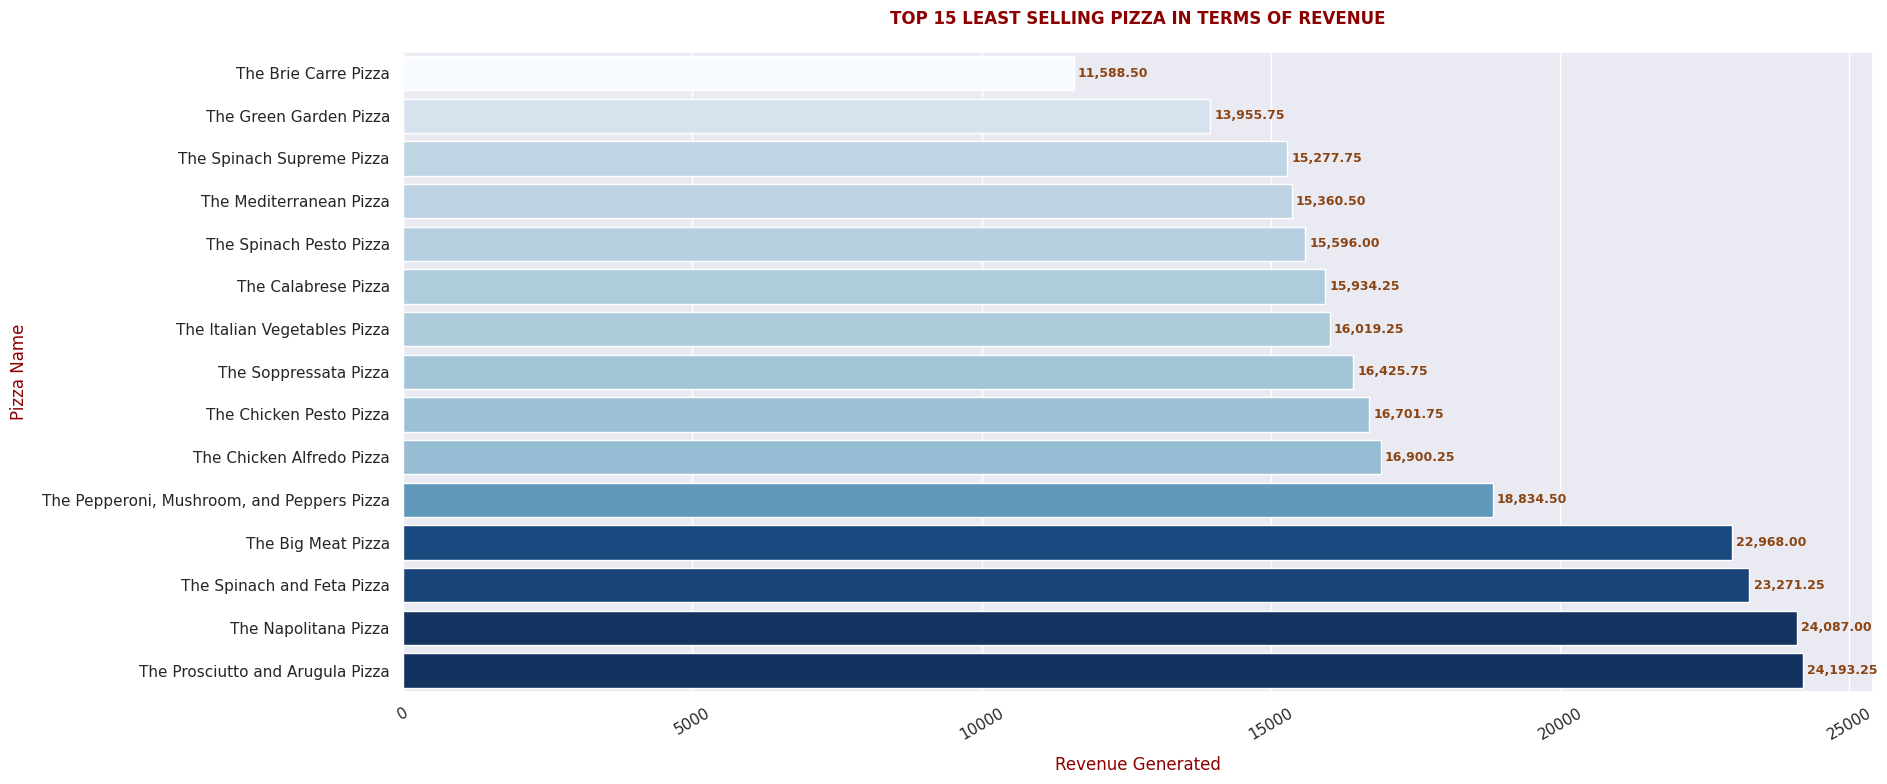

In [ ]:
#top 15 pizza leastselling pizza in terms of revenue
plt.figure(figsize=(19,8))
bars = sns.barplot(data = bottom_pizza_by_rev, y = "name", x="revenue", palette = "Blues", hue= "revenue", legend= False)
plt.title("TOP 15 LEAST SELLING PIZZA IN TERMS OF REVENUE", pad=20, color = "darkred", fontweight = "bold")
plt.ylabel("Pizza Name", labelpad=10, color = "darkred")
plt.xlabel ("Revenue Generated", labelpad=10, color = "darkred")
plt.tight_layout()

plt.xticks(range(0, 25001, 5000), rotation=30)
plt.tight_layout()
for i in bars.containers:
    bars.bar_label(i, fmt="{:,.2f}", padding=3, fontsize=9, fontweight="bold", color= "saddlebrown")


plt.show()

In [ ]:
bottom_5_pizza_by_rev= bottom_pizza_by_rev.head()
bottom_5_pizza_by_rev

,name,revenue
2,The Brie Carre Pizza,11588.50
11,The Green Garden Pizza,13955.75
28,The Spinach Supreme Pizza,15277.75
16,The Mediterranean Pizza,15360.50
27,The Spinach Pesto Pizza,15596.00


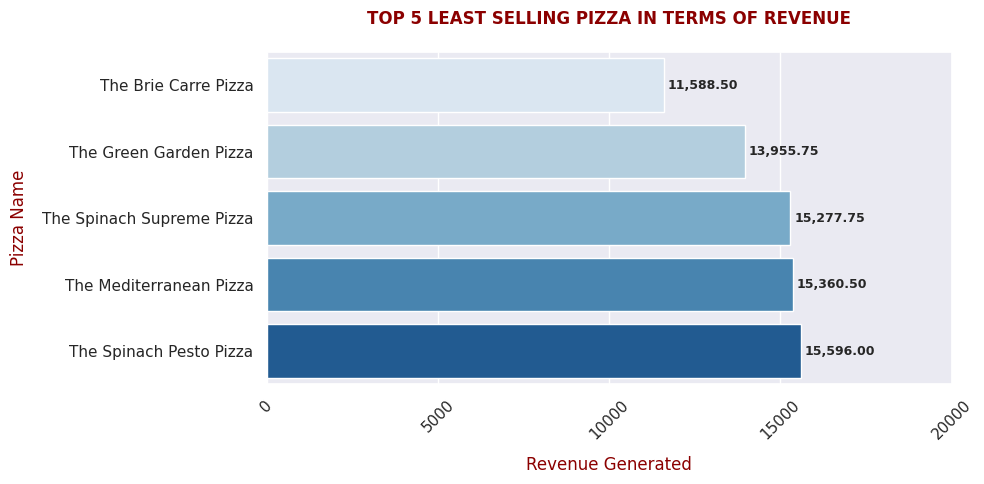

In [ ]:
#top 5 least selling pizza in terms of revenue
plt.figure(figsize=(10,5))
bars = sns.barplot(data = bottom_5_pizza_by_rev, y = "name", x="revenue", palette = "Blues", hue= "name", legend= False)
plt.title("TOP 5 LEAST SELLING PIZZA IN TERMS OF REVENUE", pad=20, color = "darkred", fontweight = "bold")
plt.ylabel("Pizza Name", labelpad=10, color = "darkred")
plt.xlabel ("Revenue Generated", labelpad=10, color = "darkred")

plt.xticks(range(0, 20001, 5000), rotation= 45)
plt.tight_layout()
for i in bars.containers:
    bars.bar_label(i, fmt="{:,.2f}", padding=3, fontsize=9, fontweight="bold")
plt.tight_layout()

plt.show()

In [ ]:
pizza_info.groupby(["category", "ingredients"])["name"].value_counts()

category  ingredients                                                                                        name                                      
Chicken   Barbecued Chicken, Red Peppers, Green Peppers, Tomatoes, Red Onions, Barbecue Sauce                The Barbecue Chicken Pizza                    2372
          Chicken, Artichoke, Spinach, Garlic, Jalapeno Peppers, Fontina Cheese, Gouda Cheese                The California Chicken Pizza                  2302
          Chicken, Pineapple, Tomatoes, Red Peppers, Thai Sweet Chilli Sauce                                 The Thai Chicken Pizza                        2315
          Chicken, Red Onions, Red Peppers, Mushrooms, Asiago Cheese, Alfredo Sauce                          The Chicken Alfredo Pizza                      980
          Chicken, Tomatoes, Red Peppers, Red Onions, Jalapeno Peppers, Corn, Cilantro, Chipotle Sauce       The Southwest Chicken Pizza                   1885
          Chicken, Tomatoes, Red Peppers, Spinach, Garlic, Pesto Sauce                                       The Chicken Pesto Pizza                        961
Classic   Bacon, Pepperoni, Italian Sausage, Chorizo Sausage                                                 The Big Meat Pizza                            1811
          Capocollo, Red Peppers, Tomatoes, Goat Cheese, Garlic, Oregano                                     The Italian Capocollo Pizza                   1414
          Kalamata Olives, Feta Cheese, Tomatoes, Garlic, Beef Chuck Roast, Red Onions                       The Greek Pizza                               1406
          Mozzarella Cheese, Pepperoni                                                                       The Pepperoni Pizza                           2369
          Pepperoni, Mushrooms, Green Peppers                                                                The Pepperoni, Mushroom, and Peppers Pizza    1342
          Pepperoni, Mushrooms, Red Onions, Red Peppers, Bacon                                               The Classic Deluxe Pizza                      2416
          Sliced Ham, Pineapple, Mozzarella Cheese                                                           The Hawaiian Pizza                            2370
          Tomatoes, Anchovies, Green Olives, Red Onions, Garlic                                              The Napolitana Pizza                          1451
Supreme   Brie Carre Cheese, Prosciutto, Caramelized Onions, Pears, Thyme, Garlic                            The Brie Carre Pizza                           480
          Calabrese Salami, Capocollo, Tomatoes, Red Onions, Green Olives, Garlic                            The Italian Supreme Pizza                     1849
          Capocollo, Tomatoes, Goat Cheese, Artichokes, Peperoncini verdi, Garlic                            The Spicy Italian Pizza                       1887
          Coarse Sicilian Salami, Tomatoes, Green Olives, Luganega Sausage, Onions, Garlic                   The Sicilian Pizza                            1887
          Genoa Salami, Capocollo, Pepperoni, Tomatoes, Asiago Cheese, Garlic                                The Pepper Salami Pizza                       1422
          Nduja Salami, Pancetta, Tomatoes, Red Onions, Friggitello Peppers, Garlic                          The Calabrese Pizza                            927
          Prosciutto di San Daniele, Arugula, Mozzarella Cheese                                              The Prosciutto and Arugula Pizza              1428
          Soppressata Salami, Fontina Cheese, Mozzarella Cheese, Mushrooms, Garlic                           The Soppressata Pizza                          957
          Spinach, Red Onions, Pepperoni, Tomatoes, Artichokes, Kalamata Olives, Garlic, Asiago Cheese       The Spinach Supreme Pizza                      940
Veggie    Eggplant, Artichokes, Tomatoes, Zucchini, Red Peppers, Garlic, Pesto Sauce                         The Italian Vegetables Pizza                   975
        

From our charts above, we see that the least selling pizzas are The Brie Carre Pizza, The Green Garden Pizza, The Spinach Supreme Pizza, The Mediterranean Pizza, The Spinach Pesto Pizzayielding	**11588.50,	13955.75, 15277.75, 15360.50, 15596.00 USD** respectively in revenue for the year 2015.

2 out of them belong to the Supreme category while 3 belong to veggies category
As opposed to the best selling which contains mostly pizzas with some sort of meat, the veggies made less money. It solidies my earlier claim that people love to consume pizzas with meat in them.

# **Further exploration**

In [ ]:
#to group by category and pizza_type_id sub-category and find sales in each
sales_category = pizza_info.groupby(["category", "pizza_type_id"])["revenue"].agg(["sum", "mean"])
sales_category

sum       mean
category pizza_type_id                     
Chicken  bbq_ckn        42768.00  18.030354
         cali_ckn       41409.50  17.988488
         ckn_alfredo    16900.25  17.245153
         ckn_pesto      16701.75  17.379553
         southw_ckn     34705.75  18.411538
         thai_ckn       43434.25  18.762095
Classic  big_meat       22968.00  12.682496
         classic_dlx    38180.50  15.803187
         hawaiian       32273.25  13.617405
         ital_cpcllo    25094.00  17.746818
         napolitana     24087.00  16.600276
         pep_msh_pep    18834.50  14.034650
         pepperoni      30161.75  12.731849
         the_greek      28454.10  20.237624
Supreme  brie_carre     11588.50  24.142708
         calabrese      15934.25  17.189051
         ital_supr      33476.75  18.105327
         peppr_salami   25529.00  17.952883
         prsc_argla     24193.25  16.942052
         sicilian       30940.50  16.396661
         soppressata    16425.75  17.163793
         spicy_ital     34831.25  18.458532
         spinach_supr   15277.75  16.252926
Veggie   five_cheese    26066.50  19.180648
         four_cheese    32265.70  17.440919
         green_garden   13955.75  14.139564
         ital_veggie    16019.25  16.430000
         mediterraneo   15360.50  16.641928
         mexicana       26780.75  18.393372
         spin_pesto     15596.00  16.296761
         spinach_fet    23271.25  16.250873
         veggie_veg     24374.75  16.142219

In [ ]:
sales_category.groupby(by="category")[["sum", "mean"]].sum()

,sum,mean
category,,
Chicken,195919.50,107.817182
Classic,220053.10,123.454304
Supreme,208197.00,162.603933
Veggie,193690.45,150.916284


In [ ]:
#to use pivot tables on sales data
sales_by_cat = pizza_info.pivot_table(index="category", values="revenue", aggfunc=["sum", "mean"])
sales_by_cat.sort_values(by=("sum", "revenue"), ascending=False)

,sum,mean
,revenue,revenue
category,,
Classic,220053.10,15.093840
Supreme,208197.00,17.678271
Chicken,195919.50,18.115534
Veggie,193690.45,16.917674


In [ ]:
pizza_stat= pizza_info.select_dtypes(["float64", "int64"]).describe()
pizza_stat_2sf = round(pizza_stat,2)
pizza_stat_2sf

,order_details_id,order_id,price,quantity,revenue
count,48620.00,48620.00,48620.00,48620.00,48620.00
mean,24310.50,10701.48,16.49,1.02,16.82
std,14035.53,6180.12,3.62,0.14,4.44
min,1.00,1.00,9.75,1.00,9.75
25%,12155.75,5337.00,12.75,1.00,12.75
50%,24310.50,10682.50,16.50,1.00,16.50
75%,36465.25,16100.00,20.25,1.00,20.50
max,48620.00,21350.00,35.95,4.00,83.00


In [ ]:
pizza_info["price"].max()

35.95

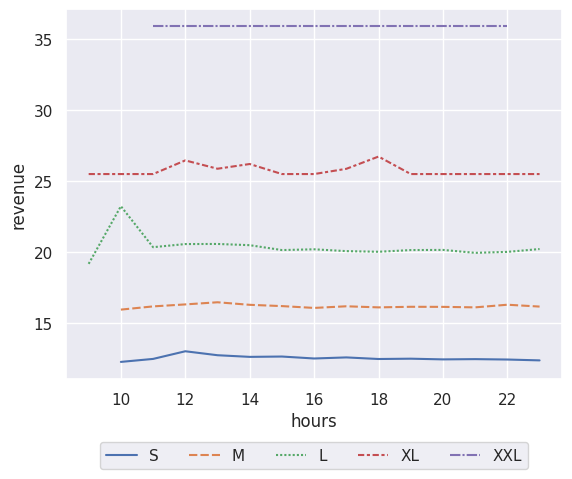

In [ ]:
sns.lineplot(data=pizza_info, x="hours", y="revenue", hue="size", style="size", errorbar=None)
plt.legend(ncol=5, bbox_to_anchor=(.5, -.15), loc="upper center")

plt.show()

---

In [ ]:
pizza_info.groupby(["hours", "category"])["revenue"].mean()

hours  category
9      Classic     21.000000
       Supreme     20.750000
       Veggie      20.250000
10     Chicken     17.892857
       Classic     14.833333
       Supreme     17.833333
       Veggie      35.900000
11     Chicken     18.139081
       Classic     15.194828
       Supreme     17.635157
       Veggie      16.913203
12     Chicken     18.242003
       Classic     15.250560
       Supreme     18.176639
       Veggie      17.292686
13     Chicken     18.406069
       Classic     15.363777
       Supreme     17.896756
       Veggie      17.265395
14     Chicken     18.307198
       Classic     14.997621
       Supreme     17.787396
       Veggie      16.773193
15     Chicken     18.080357
       Classic     15.018764
       Supreme     17.701317
       Veggie      16.470290
16     Chicken     18.031755
       Classic     15.055866
       Supreme     17.534158
       Veggie      16.878535
17     Chicken     17.968750
       Classic     14.974352
       Supreme     17.820574
       Veggie      16.901988
18     Chicken     17.967337
       Classic     15.037888
       Supreme     17.454321
       Veggie      16.689476
19     Chicken     18.060551
       Classic     14.944980
       Supreme     17.507629
       Veggie      16.698947
20     Chicken     18.048325
       Classic     14.922019
       Supreme     17.384535
       Veggie      16.964185
21     Chicken     17.931661
       Classic     15.084483
       Supreme     17.241354
       Veggie      16.676930
22     Chicken     17.927445
       Classic     14.995373
       Supreme     17.040598
       Veggie      16.989457
23     Chicken     16.483333
       Classic     15.288462
       Supreme     17.333333
       Veggie      16.386842
Name: revenue, dtype: float64

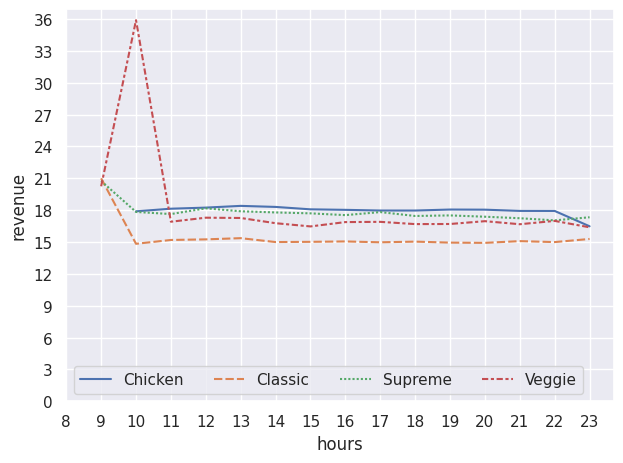

In [ ]:
sns.lineplot(data=pizza_info, x="hours", y="revenue", hue="category", style="category", errorbar=None)
plt.yticks(range(0, 37, 3))
plt.xticks(range(8, 24, 1))
plt.tight_layout()
plt.legend(ncol=4)

plt.show()

In [ ]:
pizza_info.loc[(pizza_info["hours"]==10) & (pizza_info["category"]=="Veggie")]

,order_details_id,order_id,transaction date,pizza_type_id,pizza_id,name,category,ingredients,size,price,quantity,revenue,hours,day of week,week order,month name,month number
39292,7448,3283,2015-02-25 10:54:03,four_cheese,four_cheese_l,The Four Cheese Pizza,Veggie,"Ricotta Cheese, Gorgonzola Piccante Cheese, Mo...",L,17.95,2,35.9,10,Wednesday,2,February,2


In respect to revenue, at 10am, one Veggies pizza had the highest purchase at 10am and in the process of locating that data, we can see that the purchase happened once that year and it happened in the month of February. This would explainn the spike.It is negligible and may not provide us with any tangible insight.

In [ ]:
pizza_info.groupby(["hours", "size"])["revenue"].mean()

hours  size
9      L       19.166667
       XL      25.500000
10     L       23.233333
       M       15.937500
       S       12.250000
                 ...    
22     XXL     35.950000
23     L       20.210870
       M       16.152174
       S       12.357143
       XL      25.500000
Name: revenue, Length: 69, dtype: float64

In [ ]:
pizza_info.groupby(["hours", "size"])["revenue"].mean().head(25)

hours  size
9      L       19.166667
       XL      25.500000
10     L       23.233333
       M       15.937500
       S       12.250000
11     L       20.341410
       M       16.164806
       S       12.460465
       XL      25.500000
       XXL     35.950000
12     L       20.562036
       M       16.304928
       S       13.000053
       XL      26.462264
       XXL     35.950000
13     L       20.569067
       M       16.456009
       S       12.720949
       XL      25.875000
       XXL     35.950000
14     L       20.482634
       M       16.276243
       S       12.604504
       XL      26.208333
       XXL     35.950000
Name: revenue, dtype: float64

In [ ]:
pizza_info.loc[pizza_info["size"]=="XXL"]

,order_details_id,order_id,transaction date,pizza_type_id,pizza_id,name,category,ingredients,size,price,quantity,revenue,hours,day of week,week order,month name,month number
25366,3448,1528,2015-01-26 15:24:38,the_greek,the_greek_xxl,The Greek Pizza,Classic,"Kalamata Olives, Feta Cheese, Tomatoes, Garlic...",XXL,35.95,1,35.95,15,Monday,0,January,1
25367,3564,1581,2015-01-27 16:28:38,the_greek,the_greek_xxl,The Greek Pizza,Classic,"Kalamata Olives, Feta Cheese, Tomatoes, Garlic...",XXL,35.95,1,35.95,16,Tuesday,1,January,1
25368,5902,2614,2015-02-13 13:52:26,the_greek,the_greek_xxl,The Greek Pizza,Classic,"Kalamata Olives, Feta Cheese, Tomatoes, Garlic...",XXL,35.95,1,35.95,13,Friday,4,February,2
25369,6366,2813,2015-02-16 18:15:02,the_greek,the_greek_xxl,The Greek Pizza,Classic,"Kalamata Olives, Feta Cheese, Tomatoes, Garlic...",XXL,35.95,1,35.95,18,Monday,0,February,2
25370,7491,3297,2015-02-25 12:57:10,the_greek,the_greek_xxl,The Greek Pizza,Classic,"Kalamata Olives, Feta Cheese, Tomatoes, Garlic...",XXL,35.95,1,35.95,12,Wednesday,2,February,2
25371,9845,4307,2015-03-14 13:19:35,the_greek,the_greek_xxl,The Greek Pizza,Classic,"Kalamata Olives, Feta Cheese, Tomatoes, Garlic...",XXL,35.95,1,35.95,13,Saturday,5,March,3
25372,10283,4498,2015-03-17 16:22:45,the_greek,the_greek_xxl,The Greek Pizza,Classic,"Kalamata Olives, Feta Cheese, Tomatoes, Garlic...",XXL,35.95,1,35.95,16,Tuesday,1,March,3
25373,10876,4761,2015-03-21 18:10:58,the_greek,the_greek_xxl,The Greek Pizza,Classic,"Kalamata Olives, Feta Cheese, Tomatoes, Garlic...",XXL,35.95,1,35.95,18,Saturday,5,March,3
25374,13512,5927,2015-04-10 14:02:08,the_greek,the_greek_xxl,The Greek Pizza,Classic,"Kalamata Olives, Feta Cheese, Tomatoes, Garlic...",XXL,35.95,1,35.95,14,Friday,4,April,4
25375,13780,6038,2015-04-12 11:51:07,the_greek,the_greek_xxl,The Greek Pizza,Classic,"Kalamata Olives, Feta Cheese, Tomatoes, Garlic...",XXL,35.95,1,35.95,11,Sunday,6,April,4


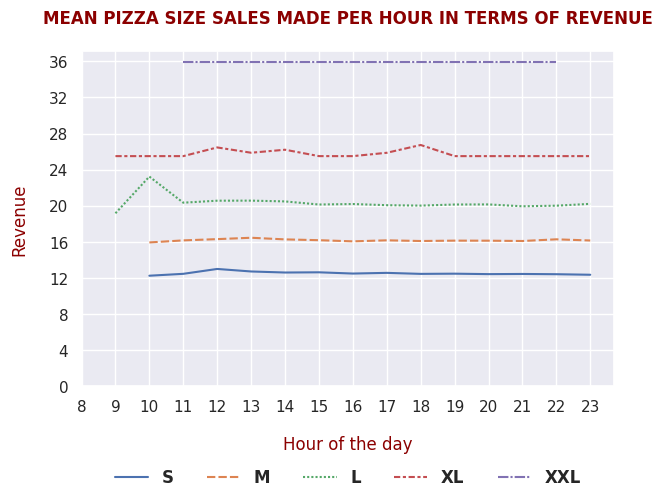

In [ ]:
sns.lineplot(data=pizza_info, x="hours", y="revenue", hue="size", style="size", errorbar=None)
plt.xlabel("Hour of the day", labelpad=15, color = "darkred")
plt.ylabel("Revenue", labelpad=15, color = "darkred")
plt.title("MEAN PIZZA SIZE SALES MADE PER HOUR IN TERMS OF REVENUE", pad=20, color = "darkred", fontweight = "bold")
plt.yticks(range(0, 37, 4))
plt.xticks(range(8, 24, 1))
plt.tight_layout()
plt.legend(ncol=5, bbox_to_anchor=(.5, -.2), loc="upper center", frameon=False, prop={"weight":"bold", "size":12})

plt.show()

The Greek Pizza in the classic category in size XXL had the highest and most consistent purchase throughout the different hours of the day starting from 11am. It was probably from a particular customer or a place with a number of persons to eat the pizza.

---
Next, I'll visualize the size disstribution using pie and donut charts.

In [ ]:
size_counts = pizza_info["size"].value_counts()
size_counts

,count
size,
L,18526
M,15385
S,14137
XL,544
XXL,28


In [ ]:
size_count = pizza_info["size"].value_counts()
size_count=size_count[size_count>1000]
size_count

,count
size,
L,18526
M,15385
S,14137


In [ ]:
size_count.index

Index(['L', 'M', 'S'], dtype='object', name='size')

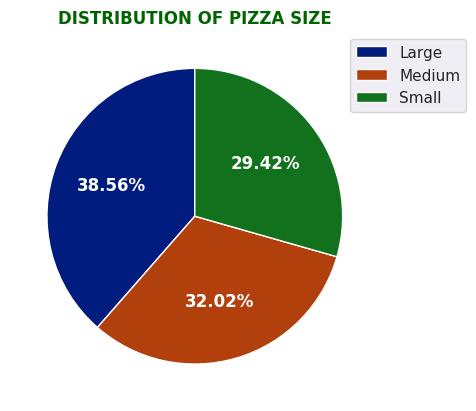

In [ ]:
plt.pie(size_count, autopct = "%1.2f%%", colors = sns.color_palette("dark"), labeldistance=0.25, pctdistance=0.6, textprops={"color": "w", "weight":"bold"}, startangle= 90)
plt.title("DISTRIBUTION OF PIZZA SIZE", color= "darkgreen", fontweight="bold" )

#to add labels and describe them, not using initials
legend_labels = ["Large", "Medium", "Small"]
plt.legend(labels=legend_labels, bbox_to_anchor= (0.9, 1))

plt.show()

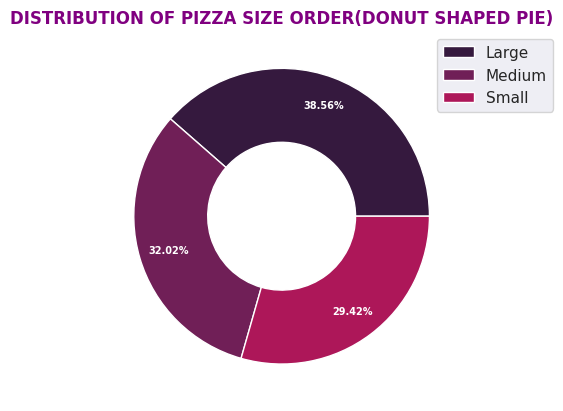

In [ ]:
plt.pie(size_count, autopct = "%1.2f%%", colors = sns.color_palette("rocket"), labeldistance=0.6, pctdistance=0.8, textprops={"color": "w", "weight":"bold", "size":"7"},wedgeprops={"width":0.5, "edgecolor":"white"})
plt.title("DISTRIBUTION OF PIZZA SIZE ORDER(DONUT SHAPED PIE)", color= "purple", fontweight="bold")
legend_labels = ["Large", "Medium", "Small"]
plt.legend(labels=legend_labels, bbox_to_anchor= (0.9, 1))

plt.show()

The piechart and donut shows the distribution of sizes. From the charts, Large has the greatest percentage. That means more people order large pizza sizes, followed by medium sizes and few people order small. The extra large and extra extra large sizes are ordered in small quantities. This is probably because they are too large to consume by oone person or even two people. Filtering it out helped me have a less jampacked chart as Extra large only occupies 1.12% of total orders (see piechart below).

In [ ]:
size_count = pizza_info["size"].value_counts()
size_count=size_count[size_count>500]
size_count

,count
size,
L,18526
M,15385
S,14137
XL,544


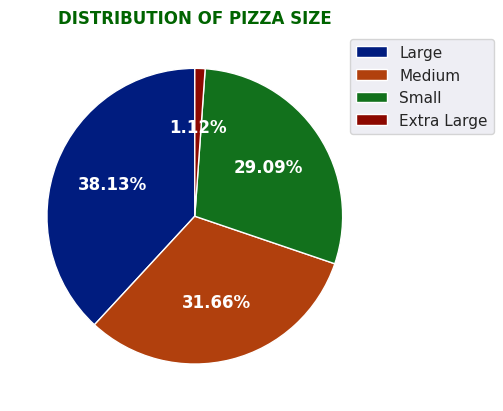

In [ ]:
plt.pie(size_count, autopct = "%1.2f%%", colors = sns.color_palette("dark"), labeldistance=0.25, pctdistance=0.6, textprops={"color": "w", "weight":"bold"}, startangle= 90)
plt.title("DISTRIBUTION OF PIZZA SIZE", color= "darkgreen", fontweight="bold" )

#to add labels and describe them, not using initials
legend_labels = ["Large", "Medium", "Small", "Extra Large"]
plt.legend(labels=legend_labels, bbox_to_anchor= (0.9, 1))

plt.show()

In [ ]:
correlation_matrix = pizza_info[["quantity", "revenue", "price"]].corr()
correlation_matrix

,quantity,revenue,price
quantity,1.000000,0.541926,0.007142
revenue,0.541926,1.000000,0.836087
price,0.007142,0.836087,1.000000


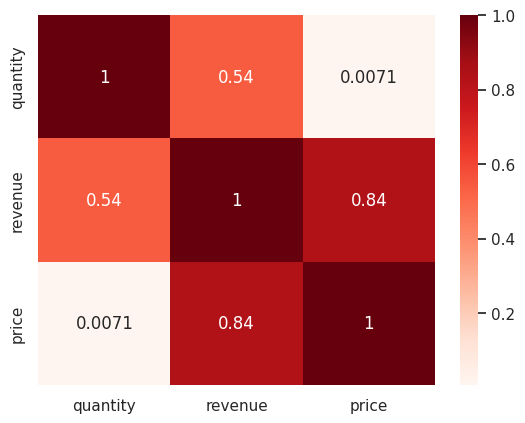

In [ ]:
sns.heatmap(correlation_matrix, annot=True, cmap= "Reds")
plt.show()

From the correlation matrix, we can tell that price has the highest correlation with revenue as it nears perfect positive correlation. This makes sense because, the higher your price, the higher the revenue. Although, quantity is also greater than 50% in correlation, a lot of othr factor havve an influeence in the quantity, hence the low correlation value.

---
A final overview of the dataset to ensure no value was missing from the cleaned dataset during **Exploratory Data Analysis (EDA)**

In [ ]:
pizza_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_details_id  48620 non-null  int64         
 1   order_id          48620 non-null  int64         
 2   transaction date  48620 non-null  datetime64[ns]
 3   pizza_type_id     48620 non-null  object        
 4   pizza_id          48620 non-null  object        
 5   name              48620 non-null  object        
 6   category          48620 non-null  object        
 7   ingredients       48620 non-null  object        
 8   size              48620 non-null  object        
 9   price             48620 non-null  float64       
 10  quantity          48620 non-null  int64         
 11  revenue           48620 non-null  float64       
 12  hours             48620 non-null  int32         
 13  day of week       48620 non-null  object        
 14  week order        4862